# K5 m=1.33 vegetation clustering — tables and figures

This notebook is the reporting/reproducibility companion for the **K=5, m=1.33**
vegetation-parent solution and its **diagnostic species subclusters**.

It intentionally **does not refit** either clustering model. Instead, it reads the
saved observation-level parent assignments from `K5_m1p33` and the saved projected
diagnostic subcluster assignments from `K5_m1p33_Subclusters`, then applies the same
table and figure logic used in `Veg_Clustering_TabsFigs`.

Important interpretation: the species subclusters here are the **best-by-silhouette
diagnostic hierarchy** from the K5 subcluster notebook. They are retained as
diagnostic subclusters, not promoted to finalized ecological states.


In [1]:
# =============================================================================
# 1. IMPORTS, PATHS, AND FIXED REPORTING SETTINGS
# =============================================================================

from __future__ import annotations

from pathlib import Path
import math
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from matplotlib.patches import Rectangle

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)

# -----------------------------------------------------------------------------
# Inputs written by the K5 parent and K5 subcluster notebooks
# -----------------------------------------------------------------------------

PARENT_ASSIGNMENTS_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived"
    r"\NCA_FCM_K5_m1p33_parent_assignments.csv"
)

PARENT_CENTROIDS_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Tables"
    r"\K5_m1p33_parent_centroids_and_membership.csv"
)

SUBCLUSTER_ASSIGNMENTS_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters"
    r"\Subclusters\NCA_K5_species_subclusters_bestSilhouette_DIAGNOSTIC.csv"
)

SUBCLUSTER_ECOLOGY_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters"
    r"\Subclusters\Tables\K5_subcluster_ecological_summary_bestSilhouette_DIAGNOSTIC.csv"
)

# -----------------------------------------------------------------------------
# Reporting outputs
# -----------------------------------------------------------------------------

REPORT_DIR = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_TabsFigs"
)

TABLE_DIR = REPORT_DIR / "Tables"
FIG_DIR = REPORT_DIR / "Figures"
DERIVED_DIR = REPORT_DIR / "Derived"

for d in [REPORT_DIR, TABLE_DIR, FIG_DIR, DERIVED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

K_PARENT = 5
M_SELECTED = 1.33
CORE_MEMBERSHIP = 0.60

K5_LABELS = {
    1: "PBG",
    2: "ARTR",
    3: "Non-ARTR shrub",
    4: "Exotic forb",
    5: "EAG",
}

FG_ALL = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
    "OTHER_FG",
    "NPF_FG",
]

RIDGE_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
    "OTHER_FG": "Other",
    "NPF_FG": "NPF",
}

FG_COLORS = {
    "ARTR_FG": "#0072B2",
    "SHRUB_FG": "#009E73",
    "PBG_FG": "#56B4E9",
    "EAG_FG": "#D55E00",
    "EF_FG": "#CC79A7",
    "BAREGROUND_FG": "#E69F00",
    "BIOCRUST_FG": "#F0E442",
    "LITTER_FG": "#000000",
}

FG_LINE_COLORS = FG_COLORS.copy()
FG_LINE_COLORS["BIOCRUST_FG"] = "#9A8700"

RIDGE_MEAN_THRESHOLD = 10.0
RIDGE_BW = 0.25
N_PLACEMENT_PARENT = "upper_right"
N_PLACEMENT_SUBCLUSTER = "upper_right"

print("Parent assignments:", PARENT_ASSIGNMENTS_PATH)
print("Subcluster assignments:", SUBCLUSTER_ASSIGNMENTS_PATH)
print("Reporting outputs:", REPORT_DIR)


Parent assignments: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33\Derived\NCA_FCM_K5_m1p33_parent_assignments.csv
Subcluster assignments: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Subclusters\NCA_K5_species_subclusters_bestSilhouette_DIAGNOSTIC.csv
Reporting outputs: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_TabsFigs


In [2]:
# =============================================================================
# 2. LOAD AND VALIDATE K5 PARENT + DIAGNOSTIC SUBCLUSTER PRODUCTS
# =============================================================================

required_paths = [
    PARENT_ASSIGNMENTS_PATH,
    SUBCLUSTER_ASSIGNMENTS_PATH,
]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(p)

veg_parent_raw = pd.read_csv(PARENT_ASSIGNMENTS_PATH, low_memory=False)
veg_states_raw = pd.read_csv(SUBCLUSTER_ASSIGNMENTS_PATH, low_memory=False)

required_parent = {
    "parent_cluster_k5",
    "max_membership_k5",
    "second_membership_k5",
    "membership_margin_k5",
    "is_reference_k5",
    *FG_ALL,
}

missing_parent = sorted(required_parent - set(veg_parent_raw.columns))
if missing_parent:
    raise ValueError(
        "K5 parent assignments are missing required columns: "
        + ", ".join(missing_parent)
    )

required_sub = {
    "parent_cluster_k5",
    "parent_label_k5",
    "max_membership_k5",
    "membership_margin_k5",
    "diagnostic_subcluster",
    "diagnostic_state_id",
    "species_total",
    *FG_ALL,
}

missing_sub = sorted(required_sub - set(veg_states_raw.columns))
if missing_sub:
    raise ValueError(
        "K5 subcluster assignments are missing required columns: "
        + ", ".join(missing_sub)
    )

if len(veg_parent_raw) != len(veg_states_raw):
    warnings.warn(
        f"Parent rows ({len(veg_parent_raw):,}) and subcluster rows "
        f"({len(veg_states_raw):,}) differ. Reporting can proceed, but inspect "
        "whether both files came from the same master."
    )

print(f"Parent rows:     {len(veg_parent_raw):,}")
print(f"Subcluster rows: {len(veg_states_raw):,}")
print(f"K5 parents:      {veg_parent_raw['parent_cluster_k5'].nunique()}")
print(
    "Diagnostic states: "
    f"{veg_states_raw['diagnostic_state_id'].dropna().nunique()}"
)


Parent rows:     1,171
Subcluster rows: 1,171
K5 parents:      5
Diagnostic states: 24


In [3]:
# =============================================================================
# 3. NORMALIZE TO THE REPORTING INTERFACE USED BY THE ORIGINAL TAB/FIG NOTEBOOK
# =============================================================================

# Parent reporting frame -------------------------------------------------------

veg_parent = veg_parent_raw.copy()

veg_parent["parent_cluster"] = (
    pd.to_numeric(veg_parent["parent_cluster_k5"], errors="raise").astype(int)
)
veg_parent["parent_label"] = veg_parent["parent_cluster"].map(K5_LABELS)

veg_parent["max_membership"] = pd.to_numeric(
    veg_parent["max_membership_k5"], errors="coerce"
)
veg_parent["second_membership"] = pd.to_numeric(
    veg_parent["second_membership_k5"], errors="coerce"
)
veg_parent["membership_margin"] = pd.to_numeric(
    veg_parent["membership_margin_k5"], errors="coerce"
)
veg_parent["is_reference"] = veg_parent["is_reference_k5"].astype(bool)

if veg_parent["parent_label"].isna().any():
    bad = sorted(veg_parent.loc[veg_parent["parent_label"].isna(), "parent_cluster"].unique())
    raise ValueError(f"Unmapped K5 parent labels: {bad}")

# Diagnostic subcluster reporting frame ---------------------------------------

veg_states = veg_states_raw.copy()

veg_states["parent_cluster"] = (
    pd.to_numeric(veg_states["parent_cluster_k5"], errors="raise").astype(int)
)
veg_states["parent_label"] = veg_states["parent_cluster"].map(K5_LABELS)

veg_states["max_membership"] = pd.to_numeric(
    veg_states["max_membership_k5"], errors="coerce"
)
veg_states["membership_margin"] = pd.to_numeric(
    veg_states["membership_margin_k5"], errors="coerce"
)

if "is_reference_k5" in veg_states.columns:
    veg_states["is_reference"] = veg_states["is_reference_k5"].astype(bool)
else:
    veg_states["is_reference"] = veg_states["max_membership"] >= CORE_MEMBERSHIP

# Preserve zero-species rows as nonvegetated/unassigned rather than forcing a
# taxonomic subcluster.
veg_states["state_id"] = veg_states["diagnostic_state_id"].astype("string")
veg_states["state_type"] = np.where(
    veg_states["state_id"].notna(),
    "vegetation_state",
    "nonvegetated",
)

veg_states["state_label"] = pd.NA

assigned = veg_states["state_id"].notna()
veg_states.loc[assigned, "state_label"] = (
    "diagnostic subcluster "
    + pd.to_numeric(
        veg_states.loc[assigned, "diagnostic_subcluster"],
        errors="coerce",
    ).astype("Int64").astype(str)
)

veg_states.loc[~assigned, "state_label"] = "zero-species / unassigned"

# Optional top-species descriptions are brought in as metadata only. They do
# not replace the neutral diagnostic state labels.
if SUBCLUSTER_ECOLOGY_PATH.exists():
    subcluster_ecology = pd.read_csv(SUBCLUSTER_ECOLOGY_PATH, low_memory=False)
else:
    subcluster_ecology = pd.DataFrame()

PARENT_LABELS = K5_LABELS

def state_sort_key(state_id: str):
    return tuple(int(v) for v in str(state_id).split("."))

print("Normalized reporting interface")
print(f"  parent clusters: {veg_parent['parent_cluster'].nunique()}")
print(
    "  diagnostic vegetation states: "
    f"{veg_states.loc[veg_states['state_type']=='vegetation_state', 'state_id'].nunique()}"
)
print(
    "  zero-species/unassigned rows: "
    f"{int((veg_states['state_type']=='nonvegetated').sum())}"
)


Normalized reporting interface
  parent clusters: 5
  diagnostic vegetation states: 24
  zero-species/unassigned rows: 6


## Table 1 — K5 parent composition and membership

This table summarizes the **observed arithmetic mean functional-group cover**
within each hard K5 parent and the membership diagnostics from the saved
\(K=5,\ m=1.33\) fuzzy solution.

If the saved parent-centroid table is present, it is retained separately as a
model-space checkpoint; the reporting table below remains observation-based so
its interpretation is directly parallel to the subcluster table.


In [4]:
# =============================================================================
# 4. TABLE 1 — K5 PARENT FG COMPOSITION + MEMBERSHIP
# =============================================================================

rows = []

for parent in sorted(veg_parent["parent_cluster"].dropna().unique()):
    g = veg_parent.loc[veg_parent["parent_cluster"] == parent].copy()

    n_ref = int(g["is_reference"].sum())

    row = {
        "parent_cluster": int(parent),
        "parent_label": K5_LABELS[int(parent)],
        "n_hard": len(g),
        "n_reference": n_ref,
        "reference_pct": 100.0 * n_ref / len(g),
        "mean_max_membership": g["max_membership"].mean(),
        "median_max_membership": g["max_membership"].median(),
        "mean_membership_margin": g["membership_margin"].mean(),
    }

    fg_means = (
        g[FG_ALL]
        .apply(pd.to_numeric, errors="coerce")
        .mean()
    )

    for fg in FG_ALL:
        row[FG_LABELS[fg]] = fg_means[fg]

    rows.append(row)

table_01 = pd.DataFrame(rows)

TABLE_01_PATH = TABLE_DIR / "Table_01_K5_Parent_FG_membership.csv"
table_01.to_csv(TABLE_01_PATH, index=False)

display(
    table_01.style
    .format({
        "reference_pct": "{:.1f}",
        "mean_max_membership": "{:.3f}",
        "median_max_membership": "{:.3f}",
        "mean_membership_margin": "{:.3f}",
        **{FG_LABELS[fg]: "{:.1f}" for fg in FG_ALL},
    })
    .hide(axis="index")
)

# Preserve the saved model centroid checkpoint in the report directory.
if PARENT_CENTROIDS_PATH.exists():
    parent_centroids = pd.read_csv(PARENT_CENTROIDS_PATH, low_memory=False)
    parent_centroids.to_csv(
        DERIVED_DIR / "K5_m1p33_parent_centroids_checkpoint.csv",
        index=False,
    )
    print("Loaded saved parent-centroid checkpoint.")
else:
    parent_centroids = pd.DataFrame()
    warnings.warn(
        f"Parent centroid file not found: {PARENT_CENTROIDS_PATH}"
    )

print("Wrote:", TABLE_01_PATH)


parent_cluster,parent_label,n_hard,n_reference,reference_pct,mean_max_membership,median_max_membership,mean_membership_margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
1,PBG,245,189,77.1,0.775,0.833,0.650,0.3,1.4,38.9,12.4,4.1,20.1,9.0,12.7,1.2,0.0
2,ARTR,146,115,78.8,0.773,0.826,0.646,24.9,3.1,12.3,8.9,3.5,13.1,20.4,13.1,0.6,0.1
3,Non-ARTR shrub,208,170,81.7,0.789,0.859,0.674,1.0,26.4,5.9,12.6,1.7,23.8,13.5,14.3,0.7,0.1
4,Exotic forb,201,170,84.6,0.804,0.867,0.694,0.4,0.5,8.3,4.3,35.0,22.7,14.3,13.8,0.6,0.0
5,EAG,371,324,87.3,0.872,0.969,0.795,1.8,2.0,4.3,65.7,3.6,9.0,1.9,11.3,0.4,0.0


Loaded saved parent-centroid checkpoint.
Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_TabsFigs\Tables\Table_01_K5_Parent_FG_membership.csv


## Table 2 — diagnostic K5 species-subcluster composition

The subcluster reporting follows the same logic as the original Tabs/Figs
notebook: all observations projected into a diagnostic subcluster contribute to
its observed functional-group means, while the parent-membership columns retain
the uncertainty of the **parent** FCM assignment.

These are explicitly diagnostic subclusters. No ecological state name is
assigned here beyond the K5 parent identity and the raw diagnostic subcluster ID.


In [5]:
# =============================================================================
# 5. TABLE 2 — DIAGNOSTIC SUBCLUSTER FG COMPOSITION
# =============================================================================

veg_only = veg_states.loc[
    veg_states["state_type"] == "vegetation_state"
].copy()

rows = []

for state_id in sorted(veg_only["state_id"].dropna().unique(), key=state_sort_key):
    g = veg_only.loc[veg_only["state_id"] == state_id].copy()

    parent = int(str(state_id).split(".")[0])
    n_ref = int(g["is_reference"].sum())

    row = {
        "parent_cluster": parent,
        "parent_label": K5_LABELS[parent],
        "state_id": state_id,
        "state_label": g["state_label"].dropna().iloc[0],
        "n_all": len(g),
        "n_reference": n_ref,
        "reference_pct": 100.0 * n_ref / len(g),
        "mean_parent_membership": g["max_membership"].mean(),
        "median_parent_membership": g["max_membership"].median(),
        "mean_parent_margin": g["membership_margin"].mean(),
    }

    fg_means = (
        g[FG_ALL]
        .apply(pd.to_numeric, errors="coerce")
        .mean()
    )

    for fg in FG_ALL:
        row[FG_LABELS[fg]] = fg_means[fg]

    if not subcluster_ecology.empty and "top_species_mean_cover" in subcluster_ecology.columns:
        hit = subcluster_ecology.loc[
            subcluster_ecology["state_id"].astype(str).eq(str(state_id)),
            "top_species_mean_cover",
        ]
        row["top_species_mean_cover"] = hit.iloc[0] if len(hit) else pd.NA

    rows.append(row)

table_02 = pd.DataFrame(rows)

TABLE_02_PATH = TABLE_DIR / "Table_02_K5_Diagnostic_Subcluster_FG_membership.csv"
table_02.to_csv(TABLE_02_PATH, index=False)

display(
    table_02.style
    .format({
        "reference_pct": "{:.1f}",
        "mean_parent_membership": "{:.3f}",
        "median_parent_membership": "{:.3f}",
        "mean_parent_margin": "{:.3f}",
        **{FG_LABELS[fg]: "{:.1f}" for fg in FG_ALL},
    })
    .hide(axis="index")
)

print("Wrote:", TABLE_02_PATH)


parent_cluster,parent_label,state_id,state_label,n_all,n_reference,reference_pct,mean_parent_membership,median_parent_membership,mean_parent_margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF,top_species_mean_cover
1,PBG,1.1,diagnostic subcluster 1,74,63,85.1,0.829,0.883,0.731,0.1,1.0,36.4,16.9,1.3,20.6,8.5,13.8,1.3,0.0,AGCR:31.09; BRTE:16.87; POSE:4.60; OTHER:1.06; CHVI8:1.01; BAPR5:0.57; PBG:0.54; SATR12:0.36
1,PBG,1.2,diagnostic subcluster 2,106,74,69.8,0.723,0.746,0.568,0.5,1.6,40.6,9.7,7.8,18.2,9.2,11.9,0.5,0.0,POSE:38.13; BRTE:9.52; SIAL2:3.03; SATR12:1.17; BRASS:0.94; CETE5:0.90; BAPR5:0.81; KRLA2:0.76
1,PBG,1.3,diagnostic subcluster 3,23,20,87.0,0.853,0.941,0.779,0.0,0.6,39.8,9.7,1.0,23.9,5.4,19.1,0.4,0.0,PBG:33.03; BRTE:9.65; ELYMUS:3.11; POSE:1.57; PSSP6:1.53; BRASS:0.88; CHVI8:0.59; AGCR:0.58
1,PBG,1.4,diagnostic subcluster 4,16,12,75.0,0.781,0.835,0.652,0.3,2.2,45.9,9.2,0.4,19.3,13.9,5.7,3.1,0.0,PSSP6:36.73; BRTE:7.44; POSE:6.31; OTHER:2.60; CHVI8:2.24; BRBR:1.81; PBG:1.44; ELEL5:1.34
1,PBG,1.5,diagnostic subcluster 5,26,20,76.9,0.763,0.836,0.639,0.1,1.9,34.0,15.4,1.7,23.0,9.8,11.1,2.9,0.0,BRTE:15.40; ACTH7:9.48; ELYMUS:8.84; HECO:4.46; ELEL5:3.55; POSE:2.69; FORB:2.15; PBG:2.06
2,ARTR,2.1,diagnostic subcluster 1,12,11,91.7,0.823,0.881,0.718,22.2,6.9,14.6,1.4,0.0,19.3,23.5,8.5,3.5,0.0,ARTR2:22.15; AGCR:7.83; CHVI8:6.76; POSE:3.71; OTHER:2.72; BRTE:1.42; PBG:1.26; PSSP6:1.25
2,ARTR,2.2,diagnostic subcluster 2,49,39,79.6,0.776,0.822,0.656,22.0,3.1,7.8,21.8,0.9,14.0,16.4,13.6,0.4,0.0,ARTR2:21.92; BRTE:21.75; POSE:6.99; SATR12D:1.63; KRLA2:1.34; ATCO:0.77; CETE5:0.51; CHVI8:0.48
2,ARTR,2.3,diagnostic subcluster 3,58,45,77.6,0.787,0.848,0.660,26.1,2.9,20.8,3.6,5.0,8.2,22.6,10.5,0.2,0.1,ARTR2:25.38; POSE:19.41; CETE5:2.33; SIAL2:1.59; KRLA2:1.58; BRTE:1.32; ATCO:1.22; ELEL5:0.92
2,ARTR,2.4,diagnostic subcluster 4,27,20,74.1,0.714,0.793,0.566,28.7,1.9,1.1,0.5,6.7,19.0,21.8,19.6,0.5,0.2,ARTR2:28.55; CETE5:5.89; SATR12D:3.33; KRLA2:1.80; POSE:0.67; SIAL2:0.47; BRTE:0.44; OTHER:0.43
3,Non-ARTR shrub,3.1,diagnostic subcluster 1,45,33,73.3,0.723,0.739,0.562,2.4,20.0,2.2,24.7,0.9,28.5,8.0,12.4,0.8,0.0,BRTE:24.40; SAVE4:7.88; ERNA10:3.99; ATCA2:2.77; ARTR2:2.36; TEGL:1.48; POSE:0.97; GRSP:0.92


Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_TabsFigs\Tables\Table_02_K5_Diagnostic_Subcluster_FG_membership.csv



## Line-only Tufte ridge atlas

Graphical grammar:

- **colored curve:** KDE of positive cover values only
- **vertical mark at 0:** fraction of observations with zero cover
- **vertical mean line:** mean observed cover, extending to the height of that FG's own ridge
- **horizontal segment below baseline:** interquartile range of the complete observed distribution
- **short vertical tick below baseline:** median of the complete observed distribution
- **no density fill**

The density height is normalized within each FG because ridge height is only a shape cue; cover magnitude remains on the common 0–100% x-axis.

`RIDGE_MEAN_THRESHOLD = 10` is a display-only filter: an FG is drawn within a cluster/state only when its observed mean cover exceeds 10%. Set it to `None` to show all eight plotted FGs. This does not alter clustering.

Sample-size placement is deliberately parameterized. Start with `upper_right`; change either setting to `title` or `none` and rerun the corresponding figure cell.


In [6]:

# =============================================================================
# 8. TUFTE RIDGE HELPERS — LINE ONLY, NO FILL
# =============================================================================

def dotted_sort(values):
    def key(v):
        s = str(v)
        if "." in s and all(p.isdigit() for p in s.split(".")):
            return tuple(int(p) for p in s.split("."))
        try:
            return (int(float(s)),)
        except Exception:
            return (10_000, s)
    return sorted(values, key=key)


def _safe_kde(values, x_grid, bw_method):
    if len(values) < 5 or len(np.unique(values)) < 3:
        return None

    try:
        kde = gaussian_kde(values, bw_method=bw_method)
        density = kde(x_grid)
    except np.linalg.LinAlgError:
        return None

    if not np.isfinite(density).all() or density.max() <= 0:
        return None

    return density


def tufte_ridge_atlas(
    data: pd.DataFrame,
    *,
    group_col: str,
    label_col: str,
    fg_cols=RIDGE_FGS,
    mean_threshold=10.0,
    bw_method=0.25,
    ridge_height=0.70,
    ncols=2,
    panels_per_fig=8,
    n_placement="upper_right",
    xlim=(0, 100),
    figure_stem="Tufte_ridges",
    panel_title_prefix="",
    show_iqr=True,
    show_median=True,
    show_mean=True,
    save=True,
):
    """
    Build a paged, line-only Tufte ridge atlas.

    n_placement:
        "upper_right" -> small n inside upper-right panel corner
        "title"       -> append n to the panel title
        "none"        -> omit sample size
    """

    if n_placement not in {"upper_right", "title", "none"}:
        raise ValueError("n_placement must be 'upper_right', 'title', or 'none'.")

    work = data.copy()
    group_vals = dotted_sort(work[group_col].dropna().unique().tolist())

    x_grid = np.linspace(max(0.01, xlim[0]), xlim[1], 700)

    figures = []

    for page_no, start in enumerate(
        range(0, len(group_vals), panels_per_fig),
        start=1
    ):
        current = group_vals[start:start + panels_per_fig]
        n_panels = len(current)
        nrows = math.ceil(n_panels / ncols)

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(6.6 * ncols, 4.15 * nrows),
            sharex=True,
        )
        axes = np.atleast_1d(axes).ravel()

        for ax, group_val in zip(axes, current):
            g = work[work[group_col] == group_val].copy()
            n_group = len(g)

            means = (
                g[fg_cols]
                .apply(pd.to_numeric, errors="coerce")
                .mean()
            )

            if mean_threshold is None:
                retained = list(fg_cols)
            else:
                retained = [
                    fg for fg in fg_cols
                    if means.get(fg, np.nan) > mean_threshold
                ]

            # Keep deterministic ecological ordering rather than sorting by mean.
            y_positions = np.arange(len(retained), 0, -1)

            for y, fg in zip(y_positions, retained):
                values = (
                    pd.to_numeric(g[fg], errors="coerce")
                    .dropna()
                    .to_numpy(dtype=float)
                )

                if len(values) == 0:
                    continue

                line_color = FG_LINE_COLORS[fg]

                # Thin reference baseline.
                ax.hlines(
                    y, xlim[0], xlim[1],
                    color="0.88",
                    linewidth=0.65,
                    zorder=0,
                )

                positive = values[values > 0]
                density = _safe_kde(positive, x_grid, bw_method)

                ridge = None
                if density is not None:
                    density = density / density.max() * ridge_height
                    ridge = y + density

                    # LINE ONLY — deliberately no fill_between().
                    ax.plot(
                        x_grid,
                        ridge,
                        color=line_color,
                        linewidth=1.35,
                        zorder=3,
                    )

                # Explicit zero mass.
                zero_fraction = np.mean(values == 0)
                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        y,
                        y + ridge_height * zero_fraction,
                        color=line_color,
                        linewidth=2.2,
                        zorder=4,
                    )

                q25, median, q75 = np.quantile(
                    values,
                    [0.25, 0.50, 0.75]
                )

                # IQR sits just below the baseline so it does not obscure the ridge.
                if show_iqr:
                    ax.hlines(
                        y - 0.10,
                        q25,
                        q75,
                        color=line_color,
                        linewidth=1.8,
                        zorder=5,
                    )

                if show_median:
                    ax.vlines(
                        median,
                        y - 0.17,
                        y - 0.03,
                        color=line_color,
                        linewidth=1.3,
                        zorder=5,
                    )

                # Mean line extends to the top of its OWN density curve.
                if show_mean:
                    mean_x = float(np.mean(values))

                    if ridge is not None:
                        mean_top = float(np.interp(mean_x, x_grid, ridge))
                    else:
                        mean_top = y + 0.16

                    ax.vlines(
                        mean_x,
                        y,
                        mean_top,
                        color=line_color,
                        linewidth=1.25,
                        zorder=6,
                    )

            # Direct colored FG labels on y-axis.
            ax.set_yticks(y_positions)
            ax.set_yticklabels([FG_LABELS[fg] for fg in retained], fontsize=8.5)

            for tick, fg in zip(ax.get_yticklabels(), retained):
                tick.set_color(FG_LINE_COLORS[fg])

            raw_label = str(g[label_col].iloc[0])
            title = f"{panel_title_prefix}{group_val} | {raw_label}"

            if n_placement == "title":
                title += f"  (n={n_group})"

            ax.set_title(title, fontsize=10, loc="left")

            if n_placement == "upper_right":
                ax.text(
                    0.985,
                    0.965,
                    f"n={n_group}",
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=8.5,
                    color="0.35",
                )

            ax.set_xlim(*xlim)
            ax.set_ylim(0.45, max(len(retained) + 1.0, 1.5))
            ax.set_xlabel("Functional-group cover (%)")

            # Tufte-style reduction of non-data ink.
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)

            ax.tick_params(axis="y", length=0)
            ax.grid(axis="x", linewidth=0.45, alpha=0.14)

        for ax in axes[n_panels:]:
            ax.axis("off")

        fig.tight_layout()

        if save:
            png_path = FIG_DIR / f"{figure_stem}_page{page_no:02d}.png"
            fig.savefig(
                png_path,
                dpi=300,
                bbox_inches="tight",
            )

        figures.append(fig)

    if save:
        pdf_path = FIG_DIR / f"{figure_stem}.pdf"
        with PdfPages(pdf_path) as pdf:
            for fig in figures:
                pdf.savefig(fig, bbox_inches="tight")

        print("Wrote:", pdf_path)

    return figures


## Figure 1 — parent-cluster Tufte ridges


NameError: name 'PdfPages' is not defined

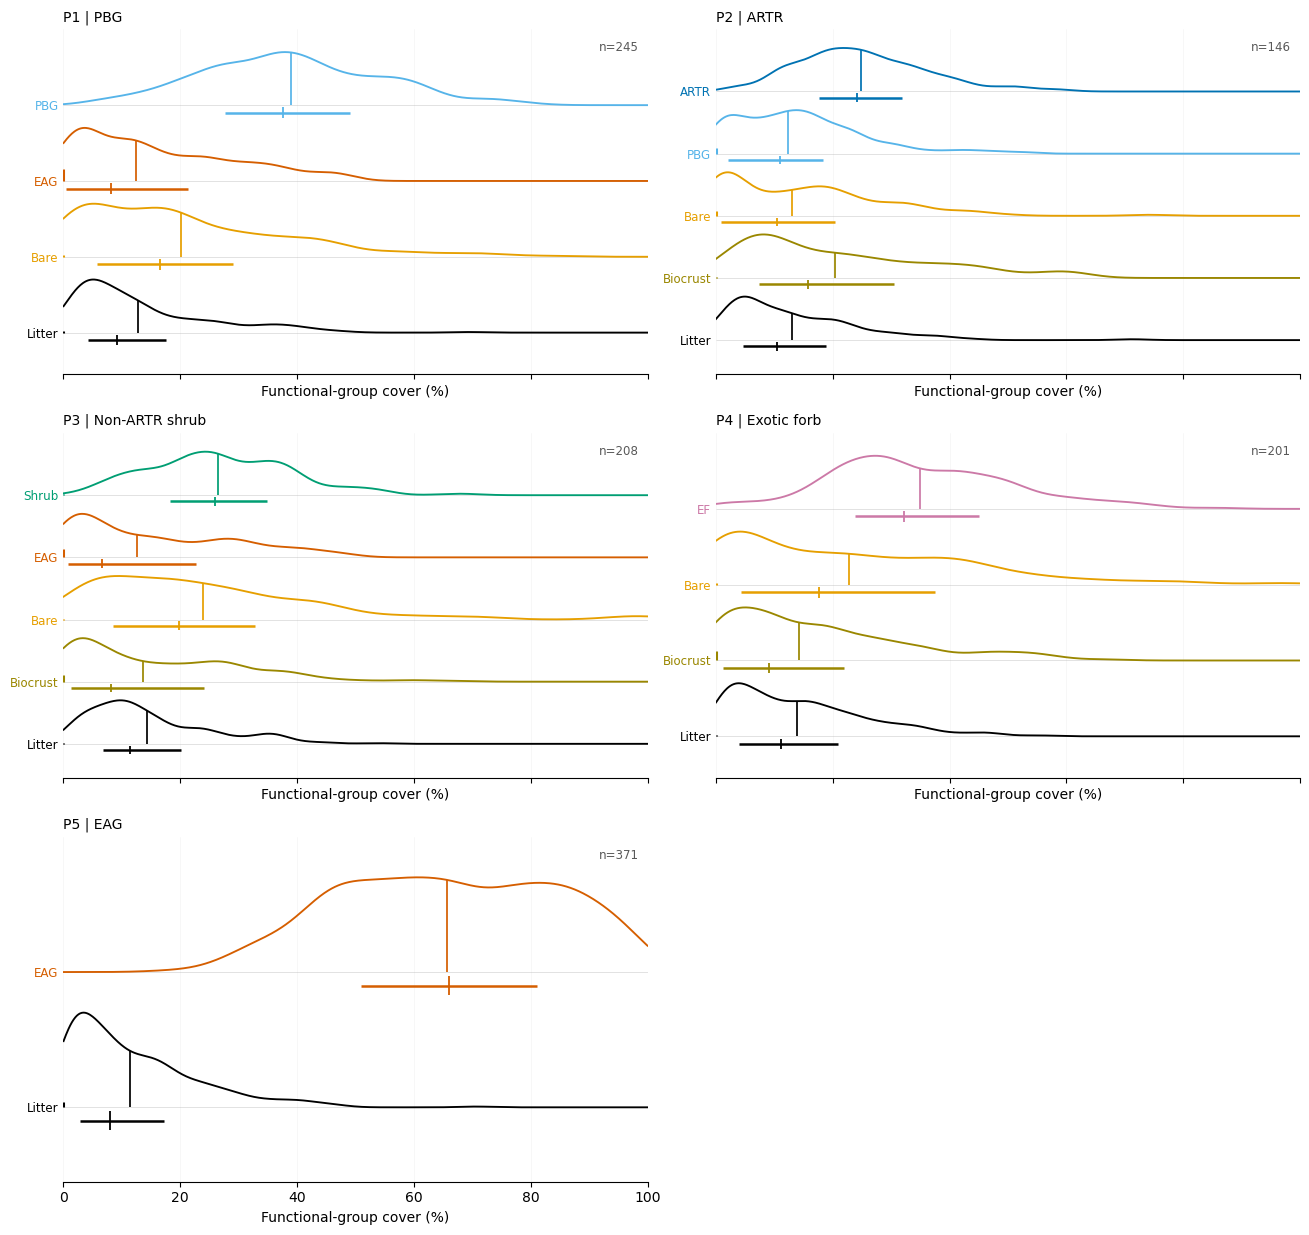

In [7]:

# =============================================================================
# 9. FIGURE 1 — PARENT CLUSTERS
# =============================================================================

parent_figs = tufte_ridge_atlas(
    veg_parent,
    group_col="parent_cluster",
    label_col="parent_label",
    fg_cols=RIDGE_FGS,
    mean_threshold=RIDGE_MEAN_THRESHOLD,
    bw_method=RIDGE_BW,
    ridge_height=0.70,
    ncols=2,
    panels_per_fig=8,
    n_placement=N_PLACEMENT_PARENT,
    figure_stem="Figure_01_Tufte_Parent_Clusters",
    panel_title_prefix="P",
)

plt.show()



## Figure 2 — K5 diagnostic species-subcluster Tufte ridges

The BG surface class is excluded because it is not a vegetation state. The plot uses all observations projected into each diagnostic K5 subcluster, while Table 3 separately reports the high-membership reference sample count.


NameError: name 'PdfPages' is not defined

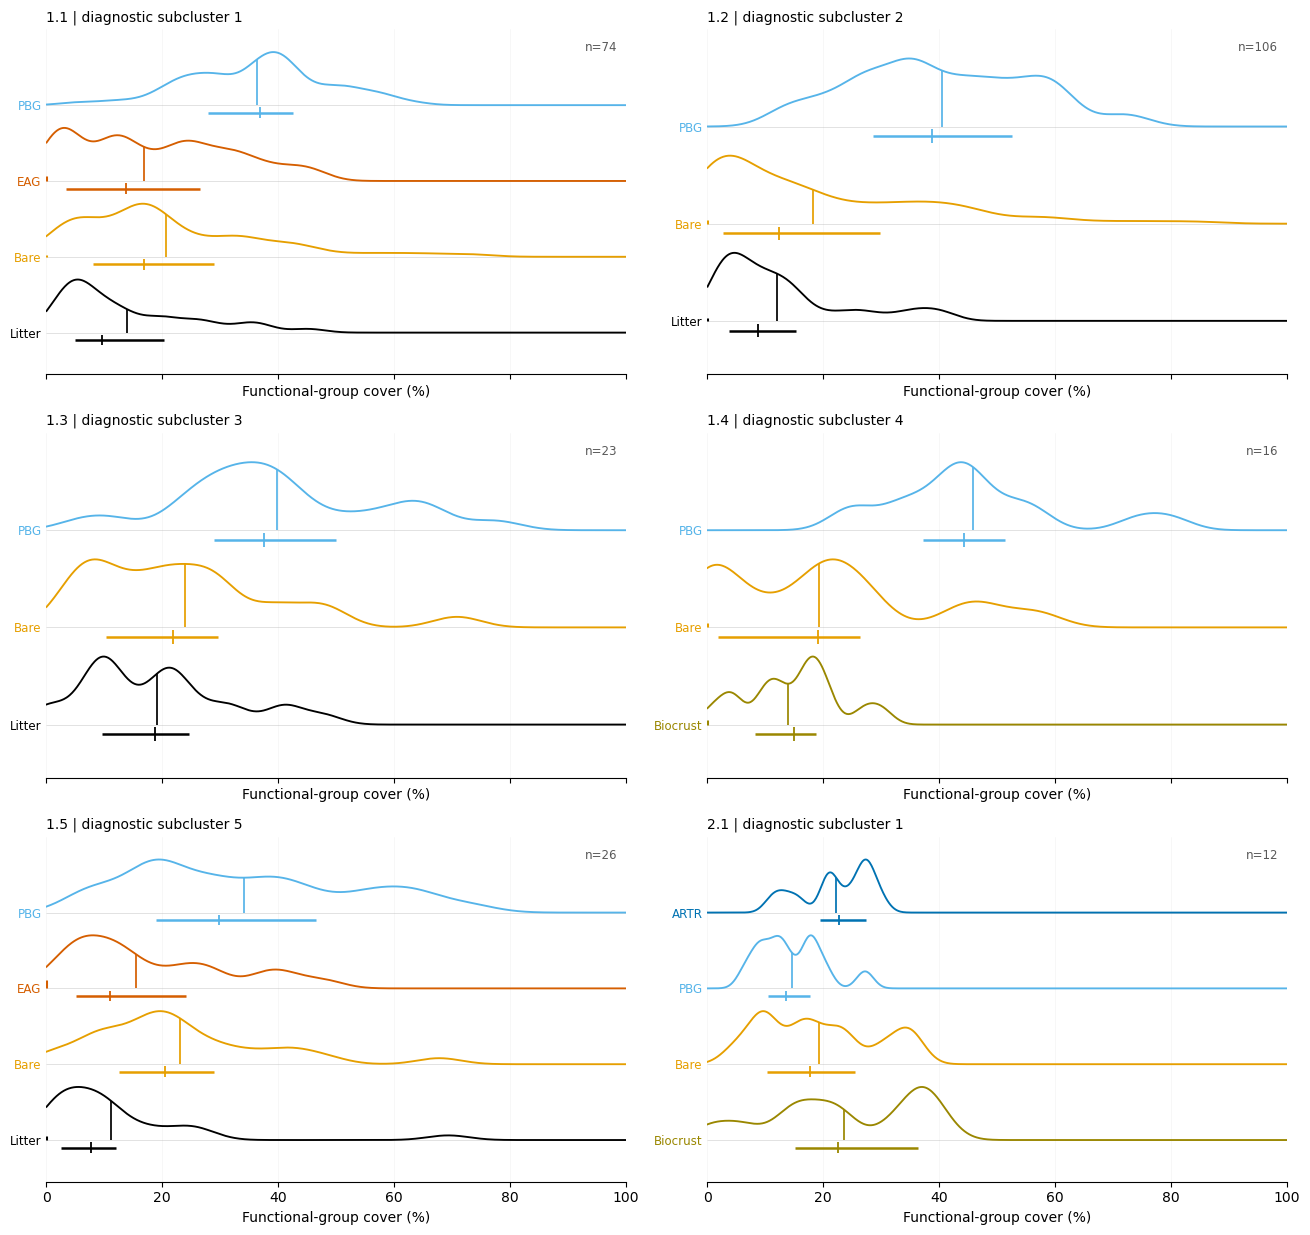

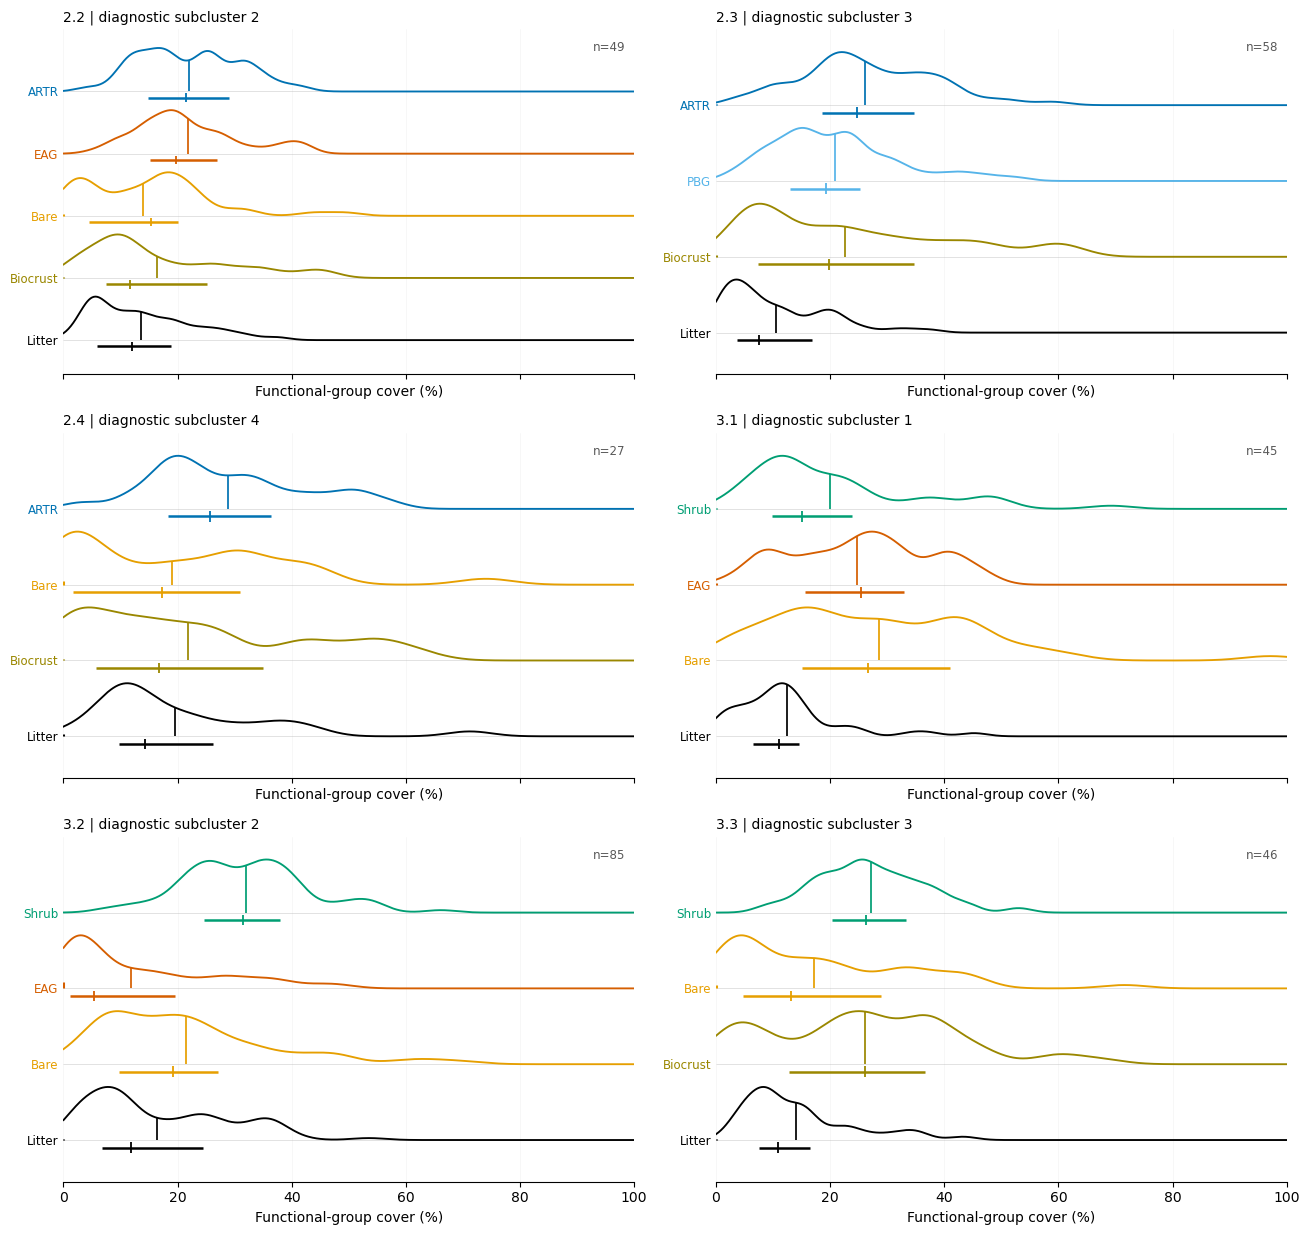

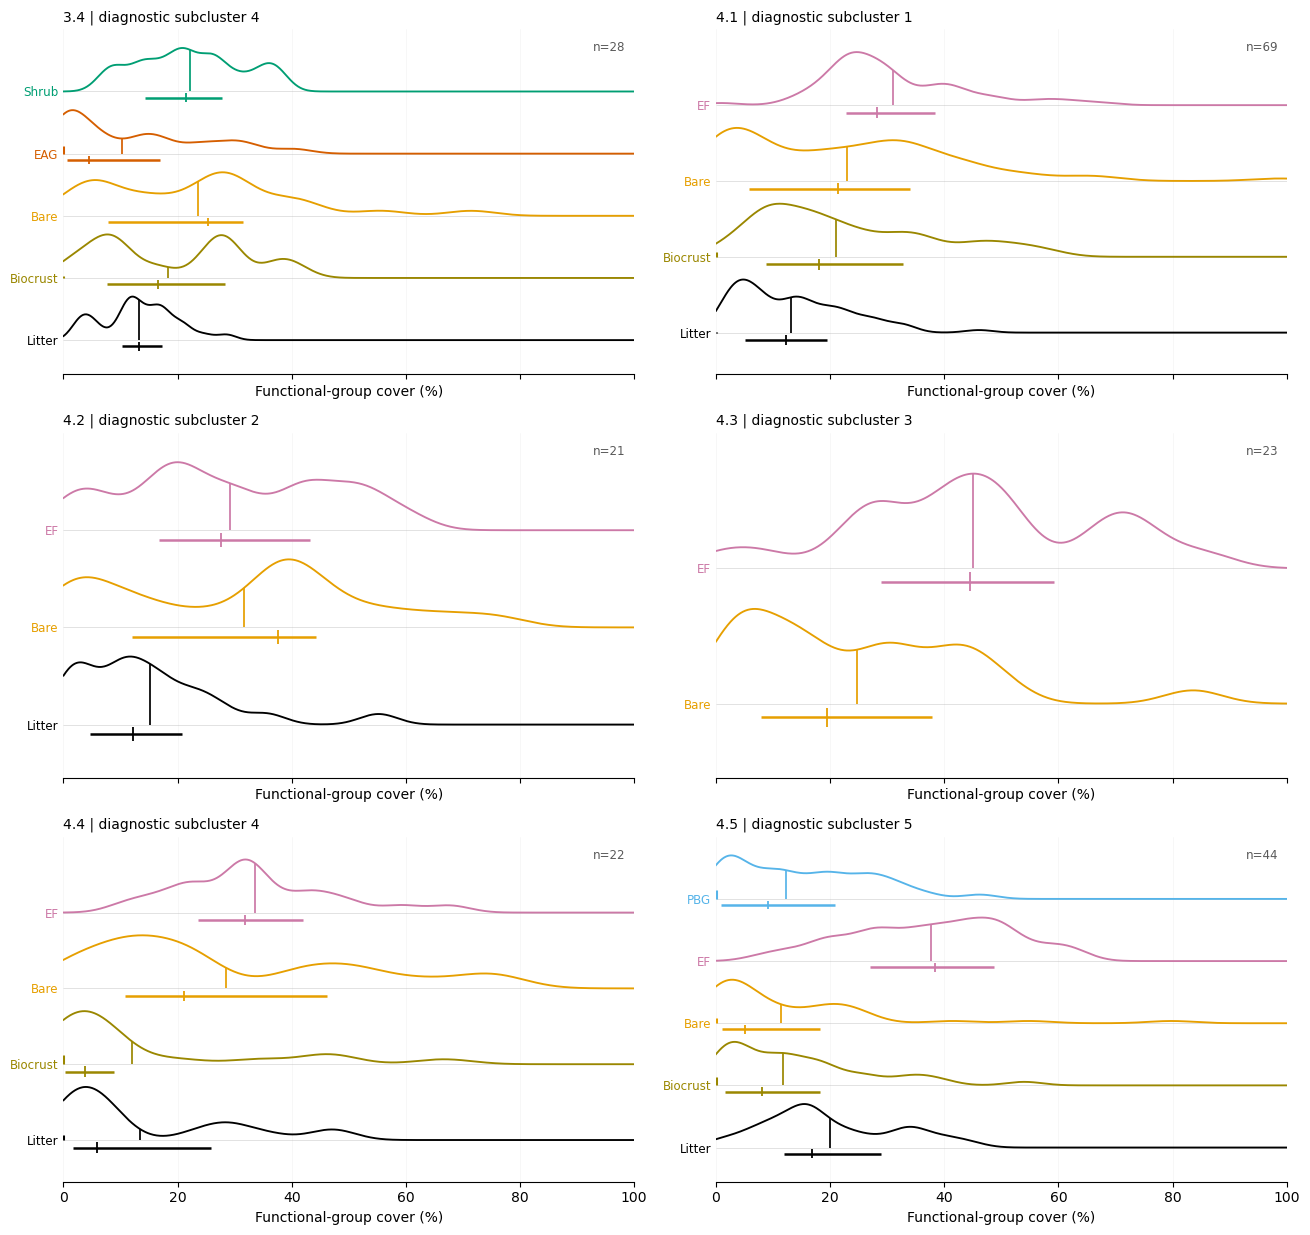

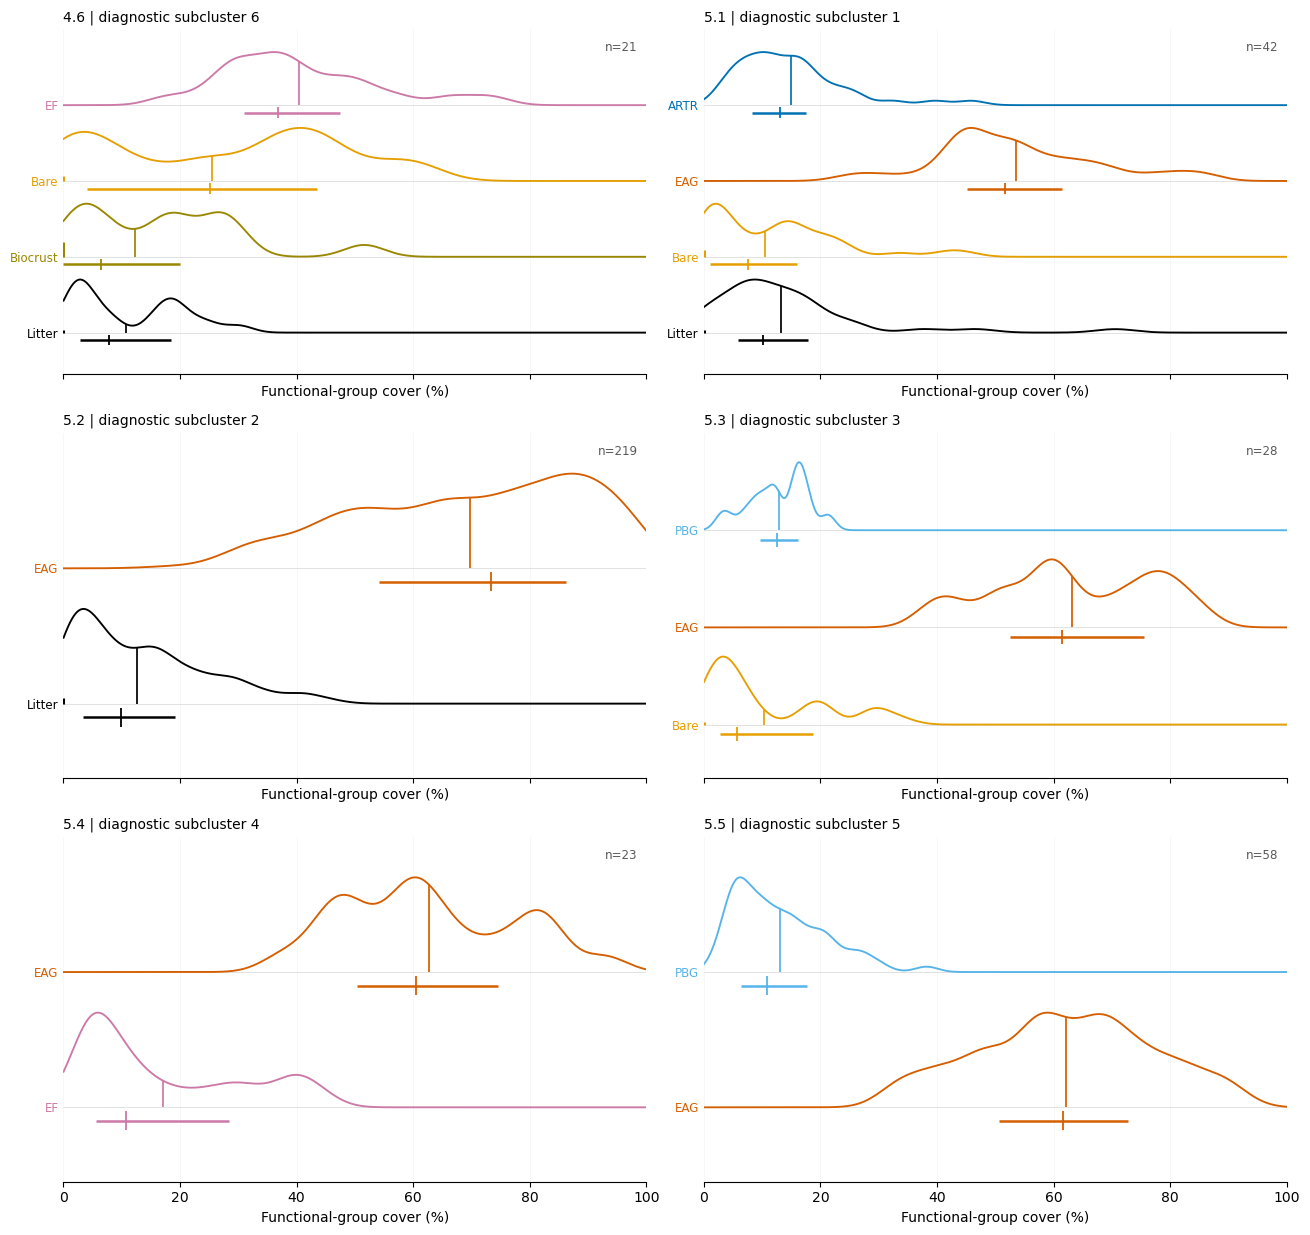

In [8]:

# =============================================================================
# 10. FIGURE 2 — K5 DIAGNOSTIC SPECIES SUBCLUSTERS
# =============================================================================

subcluster_figs = tufte_ridge_atlas(
    veg_only,
    group_col="state_id",
    label_col="state_label",
    fg_cols=RIDGE_FGS,
    mean_threshold=RIDGE_MEAN_THRESHOLD,
    bw_method=RIDGE_BW,
    ridge_height=0.70,
    ncols=2,
    panels_per_fig=6,
    n_placement=N_PLACEMENT_SUBCLUSTER,
    figure_stem="Figure_02_Tufte_Subclusters",
    panel_title_prefix="",
)

plt.show()


In [9]:
# =============================================================================
# PREVIEW ONLY: STACKED TUFTE RIDGES FOR PARENT CLUSTERS
# 2 columns x 4 rows, no export
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde


def preview_stacked_tufte_parent_ridges_grid(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=2,
    bw_method=0.25,
):
    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "Biocrust",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Okabe-Ito palette
    fg_colors = {
        "ARTR_FG": "#0072B2",
        "SHRUB_FG": "#009E73",
        "PBG_FG": "#56B4E9",
        "EAG_FG": "#D55E00",
        "EF_FG": "#CC79A7",
        "BAREGROUND_FG": "#E69F00",
        "BIOCRUST_FG": "#999000",
        "LITTER_FG": "#000000",
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    parents = sorted(
        data[cluster_col]
        .dropna()
        .unique()
    )

    n_panels = len(parents)
    nrows = ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12, 14),
        sharex=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, parent in zip(axes, parents):

        d = data.loc[
            data[cluster_col] == parent
        ].copy()

        parent_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_parent = len(d)

        # -------------------------------------------------------------
        # Display-only filtering by observed mean FG cover
        # -------------------------------------------------------------

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # Higher FG appears higher in panel
        offsets = (
            np.arange(len(keep_fgs))[::-1]
            * 1.10
        )

        for offset, fg in zip(
            offsets,
            keep_fgs,
        ):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors.get(
                fg,
                "black"
            )

            # ---------------------------------------------------------
            # Thin baseline
            # ---------------------------------------------------------

            ax.hlines(
                offset,
                0,
                x_max,
                color="0.86",
                linewidth=0.7,
                zorder=0,
            )

            # ---------------------------------------------------------
            # Positive-cover KDE
            # ---------------------------------------------------------

            positive = x[x > 0]

            xx = np.linspace(
                0.01,
                x_max,
                600
            )

            ridge = None
            yy_raw = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy = (
                            yy_raw
                            / yy_raw.max()
                        )

                        ridge = offset + yy

                        # Line only — no fill
                        ax.plot(
                            xx,
                            ridge,
                            color=color,
                            linewidth=1.6,
                            zorder=3,
                        )

                except np.linalg.LinAlgError:
                    ridge = None

            # ---------------------------------------------------------
            # Explicit zero mass
            # ---------------------------------------------------------

            zero_fraction = np.mean(
                x == 0
            )

            if zero_fraction > 0:
                ax.vlines(
                    0,
                    offset,
                    offset + zero_fraction,
                    color=color,
                    linewidth=2.0,
                    zorder=4,
                    clip_on=False,
                )

            # ---------------------------------------------------------
            # IQR + median from complete observed distribution
            # ---------------------------------------------------------

            q25, median, q75 = np.quantile(
                x,
                [0.25, 0.50, 0.75]
            )

            ax.hlines(
                offset - 0.10,
                q25,
                q75,
                color=color,
                linewidth=1.6,
                zorder=5,
            )

            ax.vlines(
                median,
                offset - 0.17,
                offset - 0.03,
                color=color,
                linewidth=1.2,
                zorder=5,
            )

            # ---------------------------------------------------------
            # Mean line — baseline to top of its own KDE curve
            # ---------------------------------------------------------

            mean_x = float(np.mean(x))

            if ridge is not None:
                mean_top = float(
                    np.interp(
                        mean_x,
                        xx,
                        ridge
                    )
                )
            else:
                mean_top = (
                    offset + 0.16
                )

            ax.vlines(
                mean_x,
                offset,
                mean_top,
                color=color,
                linewidth=1.3,
                zorder=6,
            )

            # ---------------------------------------------------------
            # Direct FG label
            # ---------------------------------------------------------

            ax.text(
                -2.5,
                offset,
                fg_pretty.get(
                    fg,
                    fg
                ),
                ha="right",
                va="center",
                fontsize=9.5,
                color=color,
            )

        # -------------------------------------------------------------
        # Panel formatting
        # -------------------------------------------------------------

        ax.set_xlim(
            0,
            x_max
        )

        ax.set_xticks(
            x_ticks
        )

        ax.set_xticklabels(
            [
                str(int(t))
                for t in x_ticks
            ]
        )

        # Force labels on every panel despite sharex=True
        ax.tick_params(
            axis="x",
            labelbottom=True
        )

        ax.set_yticks([])

        ax.set_ylim(
            -0.45,
            offsets.max() + 1.10
        )

        ax.set_title(
            f"P{parent} | {parent_name}",
            loc="left",
            fontsize=11.5,
            pad=6,
        )

        ax.text(
            0.98,
            0.94,
            f"n={n_parent}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="0.35",
        )

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        # Tufte-style reduction of non-data ink
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.tick_params(
            axis="y",
            length=0
        )

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    # Hide unused axes if necessary
    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Preview: stacked Tufte ridge plots for parent clusters",
        fontsize=14,
        y=0.995,
    )

    fig.tight_layout()

    # PREVIEW ONLY — no savefig()
    plt.show()


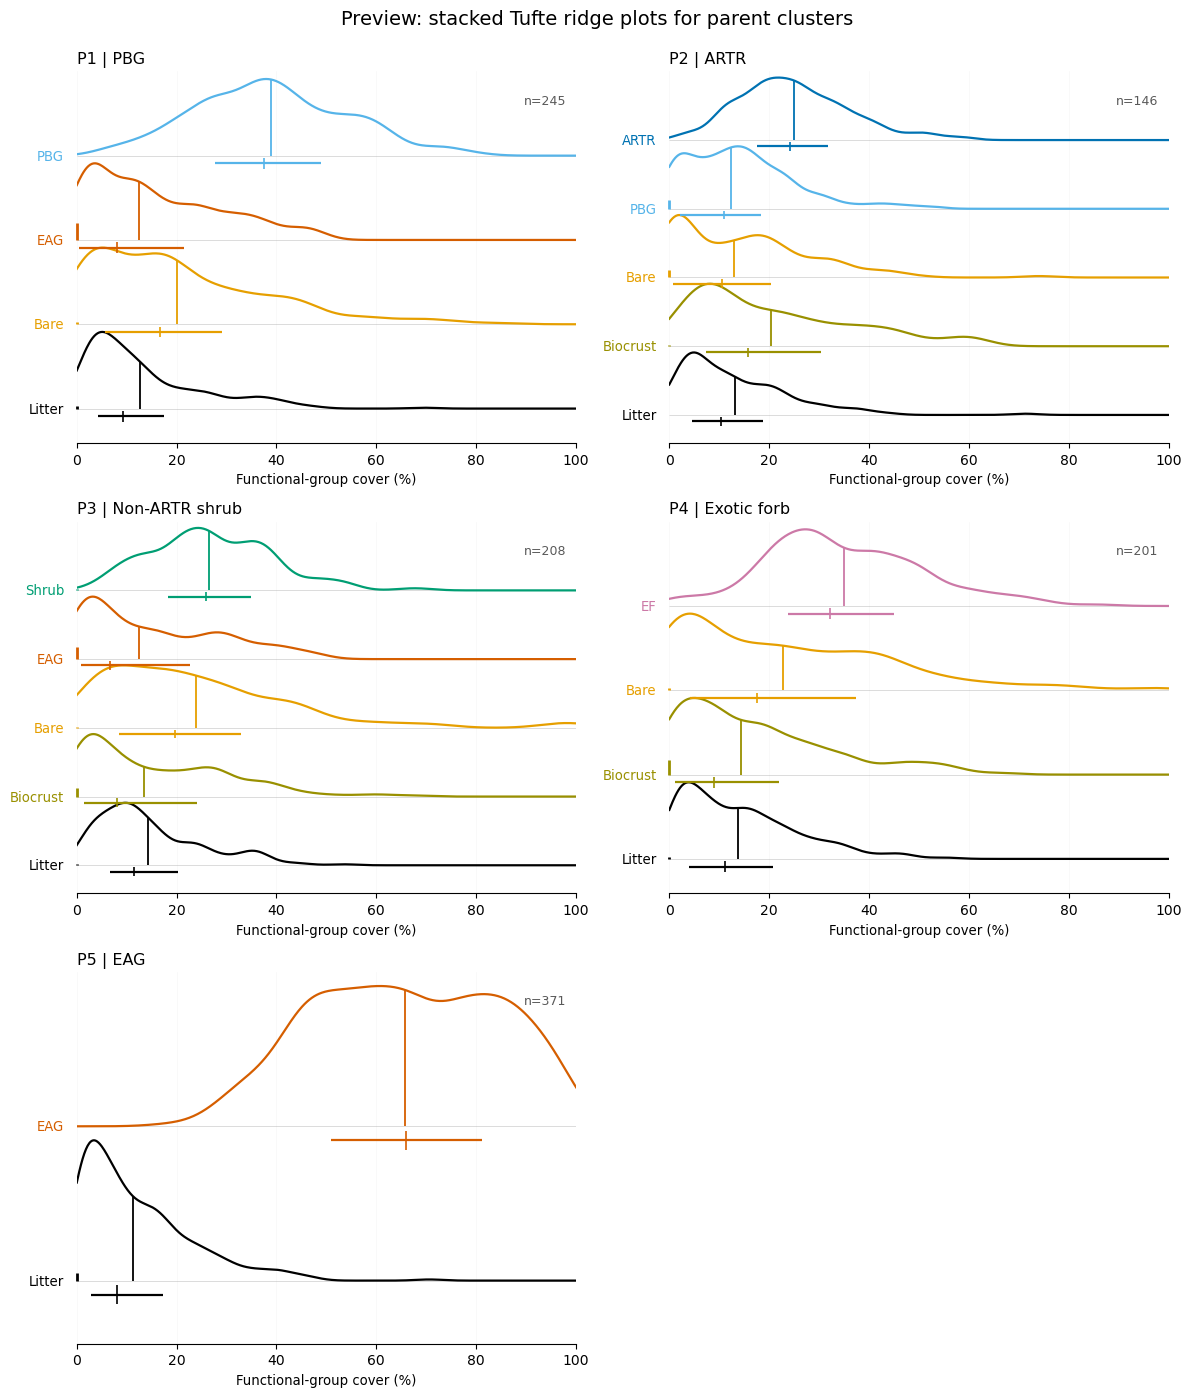

In [10]:
preview_stacked_tufte_parent_ridges_grid(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
)


In [11]:
# =============================================================================
# PREVIEW ONLY: OVERLAID SINGLE-BASELINE TUFTE DENSITIES
# 2 columns x 4 rows
# Taller panels + legends outside plotting region
# NO EXPORT
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


def preview_overlaid_tufte_parent_densities_v2(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=2,
    bw_method=0.25,
    show_iqr=True,
    show_zero_ticks=True,
):

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "Biocrust",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Okabe-Ito
    fg_colors = {
        "ARTR_FG": "#0072B2",
        "SHRUB_FG": "#009E73",
        "PBG_FG": "#56B4E9",
        "EAG_FG": "#D55E00",
        "EF_FG": "#CC79A7",
        "BAREGROUND_FG": "#E69F00",
        "BIOCRUST_FG": "#999000",
        "LITTER_FG": "#000000",
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    parents = sorted(
        data[cluster_col]
        .dropna()
        .unique()
    )

    n_panels = len(parents)
    nrows = ceil(n_panels / ncols)

    # Taller than previous version
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(13, 17),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()

    xx = np.linspace(
        0.01,
        x_max,
        700
    )

    for ax, parent in zip(axes, parents):

        d = data.loc[
            data[cluster_col] == parent
        ].copy()

        parent_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_parent = len(d)

        # -------------------------------------------------------------
        # Display-only FG filter
        # -------------------------------------------------------------

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # -------------------------------------------------------------
        # Shared baseline
        # -------------------------------------------------------------

        ax.axhline(
            0,
            color="0.80",
            linewidth=0.8,
            zorder=0
        )

        # IQR bars occupy separate shallow rows below baseline
        if show_iqr:
            iqr_offsets = np.linspace(
                -0.10,
                -0.30,
                len(keep_fgs)
            )

        legend_handles = []

        # -------------------------------------------------------------
        # Functional-group distributions
        # -------------------------------------------------------------

        for i, fg in enumerate(keep_fgs):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]

            positive = x[x > 0]

            ridge_drawn = False
            yy_scaled = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy_scaled = (
                            yy_raw /
                            yy_raw.max()
                        )

                        ax.plot(
                            xx,
                            yy_scaled,
                            color=color,
                            linewidth=1.7,
                            alpha=0.97,
                            zorder=3,
                        )

                        ridge_drawn = True

                except np.linalg.LinAlgError:
                    pass

            # ---------------------------------------------------------
            # Mean line
            # ---------------------------------------------------------

            mean_x = float(
                np.mean(x)
            )

            if ridge_drawn:
                mean_top = float(
                    np.interp(
                        mean_x,
                        xx,
                        yy_scaled
                    )
                )
            else:
                mean_top = 0.15

            ax.vlines(
                mean_x,
                0,
                mean_top,
                color=color,
                linewidth=1.25,
                zorder=4,
            )

            # ---------------------------------------------------------
            # Explicit zero mass
            # ---------------------------------------------------------

            if show_zero_ticks:

                zero_fraction = np.mean(
                    x == 0
                )

                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        0,
                        min(zero_fraction, 0.24),
                        color=color,
                        linewidth=2.0,
                        zorder=5,
                        clip_on=False,
                    )

            # ---------------------------------------------------------
            # IQR + median below baseline
            # ---------------------------------------------------------

            if show_iqr:

                q25, median, q75 = np.quantile(
                    x,
                    [0.25, 0.50, 0.75]
                )

                y_iqr = iqr_offsets[i]

                ax.hlines(
                    y_iqr,
                    q25,
                    q75,
                    color=color,
                    linewidth=1.6,
                    zorder=4,
                )

                ax.vlines(
                    median,
                    y_iqr - 0.027,
                    y_iqr + 0.027,
                    color=color,
                    linewidth=1.15,
                    zorder=4,
                )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    label=fg_pretty[fg],
                )
            )

        # -------------------------------------------------------------
        # Axes
        # -------------------------------------------------------------

        ax.set_xlim(
            0,
            x_max
        )

        ax.set_xticks(
            x_ticks
        )

        ax.set_xticklabels(
            [str(int(t)) for t in x_ticks]
        )

        ax.tick_params(
            axis="x",
            labelbottom=True,
            labelsize=9
        )

        # Slightly more vertical space for the density shape itself
        ax.set_ylim(
            -0.36,
            1.10
        )

        ax.set_yticks([])

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        # -------------------------------------------------------------
        # Panel header
        # -------------------------------------------------------------

        ax.set_title(
            f"P{parent} | {parent_name}",
            loc="left",
            fontsize=12,
            pad=35,
        )

        # Legend OUTSIDE plotting region
        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.015),
            borderaxespad=0,
            ncol=len(legend_handles),   # force one row
            fontsize=8.0,
            handlelength=1.5,
            handletextpad=0.35,
            columnspacing=0.75,
        )

        # Sample size in same header strip
        ax.text(
            1.0,
            1.035,
            f"n={n_parent}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="0.35",
            clip_on=False,
        )

        # -------------------------------------------------------------
        # Minimal styling
        # -------------------------------------------------------------

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    # unused axes
    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Functional-group distributions by parent cluster",
        fontsize=15,
        y=0.998,
    )

    # More vertical separation to accommodate external legends
    fig.subplots_adjust(
        top=0.94,
        bottom=0.05,
        left=0.06,
        right=0.985,
        hspace=0.62,
        wspace=0.18,
    )

    # PREVIEW ONLY
    plt.show()


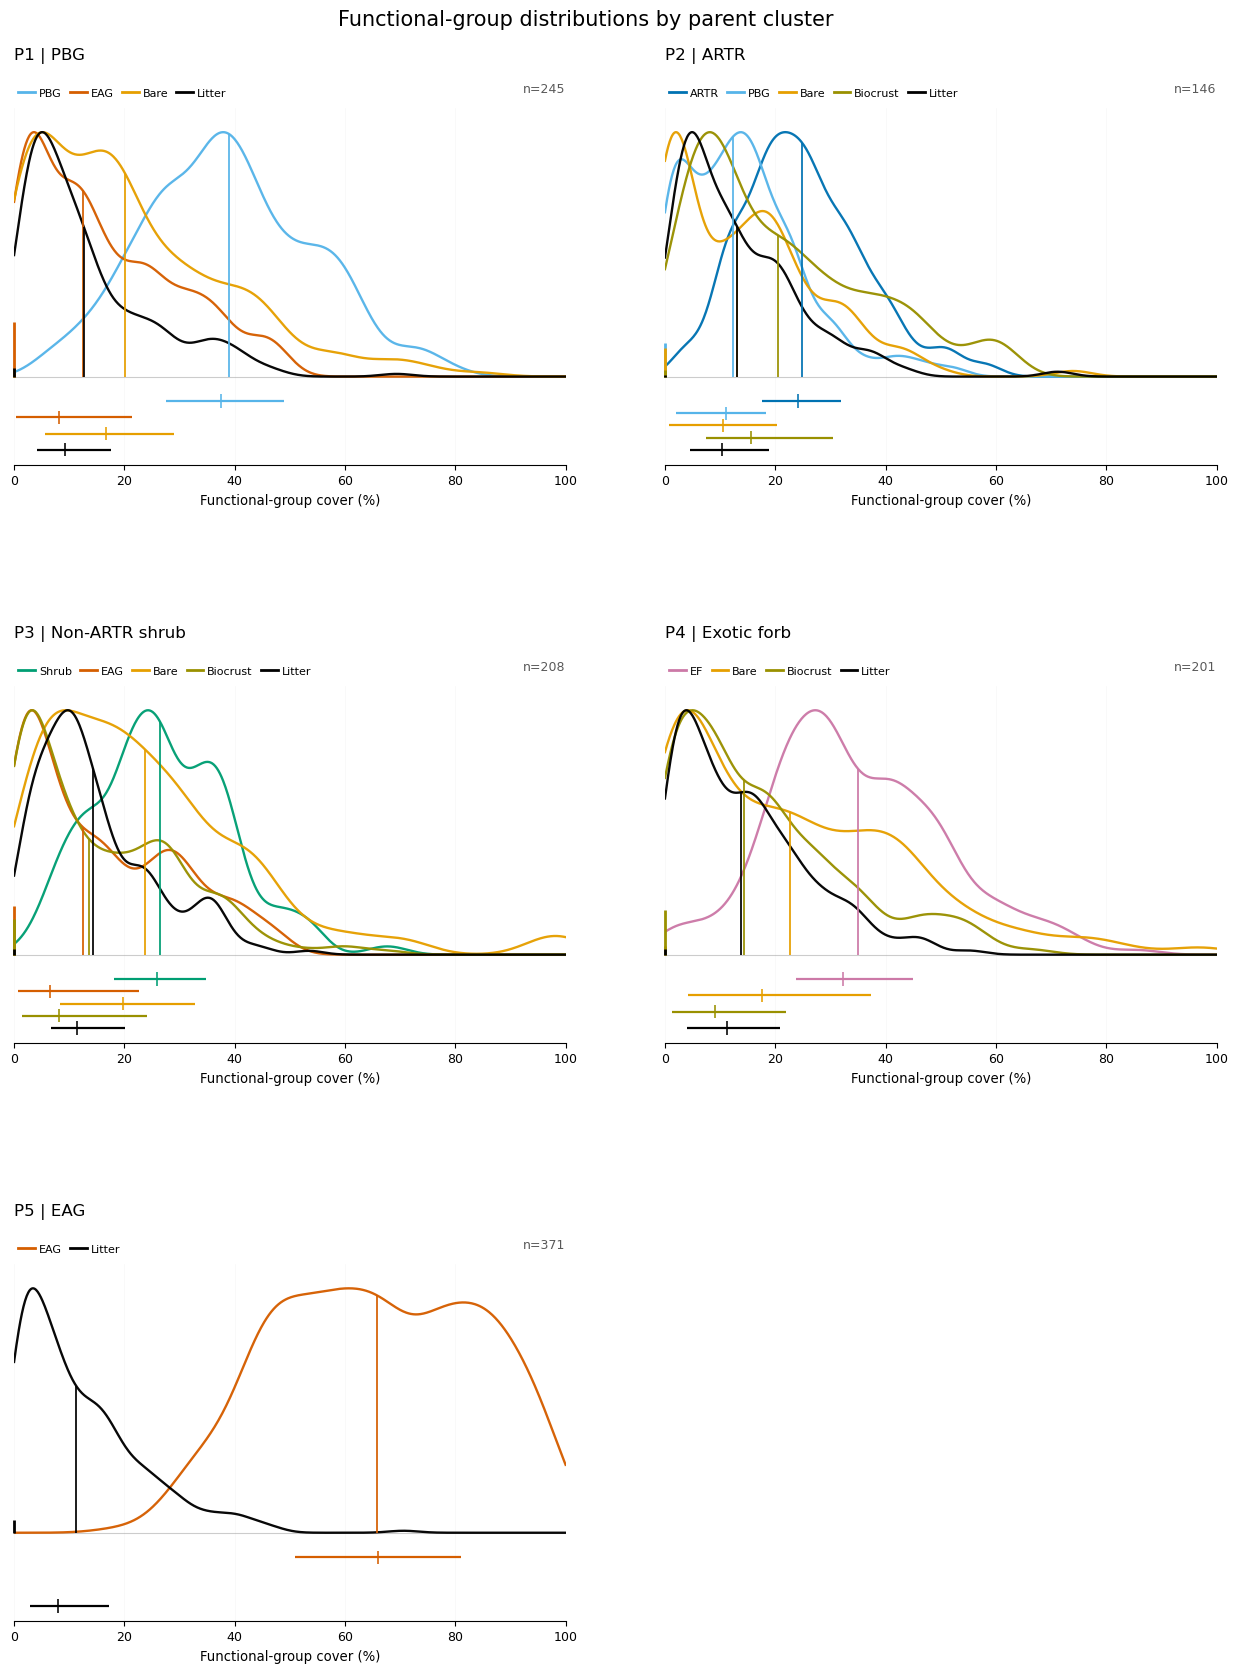

In [12]:
preview_overlaid_tufte_parent_densities_v2(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
)


In [13]:
# =============================================================================
# OVERLAID SINGLE-BASELINE TUFTE DENSITIES BY PARENT CLUSTER
# SINGLE-COLUMN VERSION: wider + shorter panels
# PREVIEW ONLY
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


def preview_overlaid_tufte_parent_densities_singlecol(
    data,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=1,
    bw_method=0.25,
    show_iqr=True,
    show_zero_ticks=True,
):

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "BSC",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Updated palette: Bare and BSC separated more clearly
    fg_colors = {
        "ARTR_FG": "#0072B2",        # blue
        "SHRUB_FG": "#009E73",       # green
        "PBG_FG": "#56B4E9",         # sky blue
        "EAG_FG": "#D55E00",         # vermillion
        "EF_FG": "#CC79A7",          # magenta
        "BAREGROUND_FG": "#8C564B",  # brown
        "BIOCRUST_FG": "#6B8E23",    # olive green
        "LITTER_FG": "#000000",      # black
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    parents = sorted(
        data[cluster_col]
        .dropna()
        .unique()
    )

    n_panels = len(parents)
    nrows = ceil(n_panels / ncols)

    # Wider and shorter panels
    panel_width = 13
    panel_height = 2.25

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width, panel_height * nrows + 1.0),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()

    xx = np.linspace(0.01, x_max, 700)

    for ax, parent in zip(axes, parents):

        d = data.loc[
            data[cluster_col] == parent
        ].copy()

        parent_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_parent = len(d)

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # shared baseline
        ax.axhline(
            0,
            color="0.82",
            linewidth=0.8,
            zorder=0
        )

        if show_iqr:
            iqr_offsets = np.linspace(
                -0.08,
                -0.22,
                len(keep_fgs)
            )

        legend_handles = []

        for i, fg in enumerate(keep_fgs):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]
            positive = x[x > 0]

            ridge_drawn = False
            yy_scaled = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy_scaled = yy_raw / yy_raw.max()

                        ax.plot(
                            xx,
                            yy_scaled,
                            color=color,
                            linewidth=1.7,
                            alpha=0.97,
                            zorder=3,
                        )

                        ridge_drawn = True

                except np.linalg.LinAlgError:
                    pass

            mean_x = float(np.mean(x))

            if ridge_drawn:
                mean_top = float(
                    np.interp(
                        mean_x,
                        xx,
                        yy_scaled
                    )
                )
            else:
                mean_top = 0.15

            ax.vlines(
                mean_x,
                0,
                mean_top,
                color=color,
                linewidth=1.25,
                zorder=4,
            )

            if show_zero_ticks:
                zero_fraction = np.mean(x == 0)
                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        0,
                        min(zero_fraction, 0.20),
                        color=color,
                        linewidth=2.0,
                        zorder=5,
                        clip_on=False,
                    )

            if show_iqr:
                q25, median, q75 = np.quantile(
                    x,
                    [0.25, 0.50, 0.75]
                )

                y_iqr = iqr_offsets[i]

                ax.hlines(
                    y_iqr,
                    q25,
                    q75,
                    color=color,
                    linewidth=1.5,
                    zorder=4,
                )

                ax.vlines(
                    median,
                    y_iqr - 0.020,
                    y_iqr + 0.020,
                    color=color,
                    linewidth=1.1,
                    zorder=4,
                )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    label=fg_pretty[fg],
                )
            )

        ax.set_xlim(0, x_max)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(int(t)) for t in x_ticks])
        ax.tick_params(axis="x", labelbottom=True, labelsize=9)

        ax.set_ylim(-0.27, 1.05)
        ax.set_yticks([])

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        ax.set_title(
            f"P{parent} | {parent_name}",
            loc="left",
            fontsize=12,
            pad=28,
        )

        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.01),
            borderaxespad=0,
            ncol=len(legend_handles),
            fontsize=8.2,
            handlelength=1.5,
            handletextpad=0.35,
            columnspacing=0.8,
        )

        ax.text(
            1.0,
            1.02,
            f"n={n_parent}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="0.35",
            clip_on=False,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Functional-group distributions by parent cluster",
        fontsize=15,
        y=0.998,
    )

    fig.subplots_adjust(
        top=0.965,
        bottom=0.04,
        left=0.07,
        right=0.985,
        hspace=0.55,
    )

    plt.show()


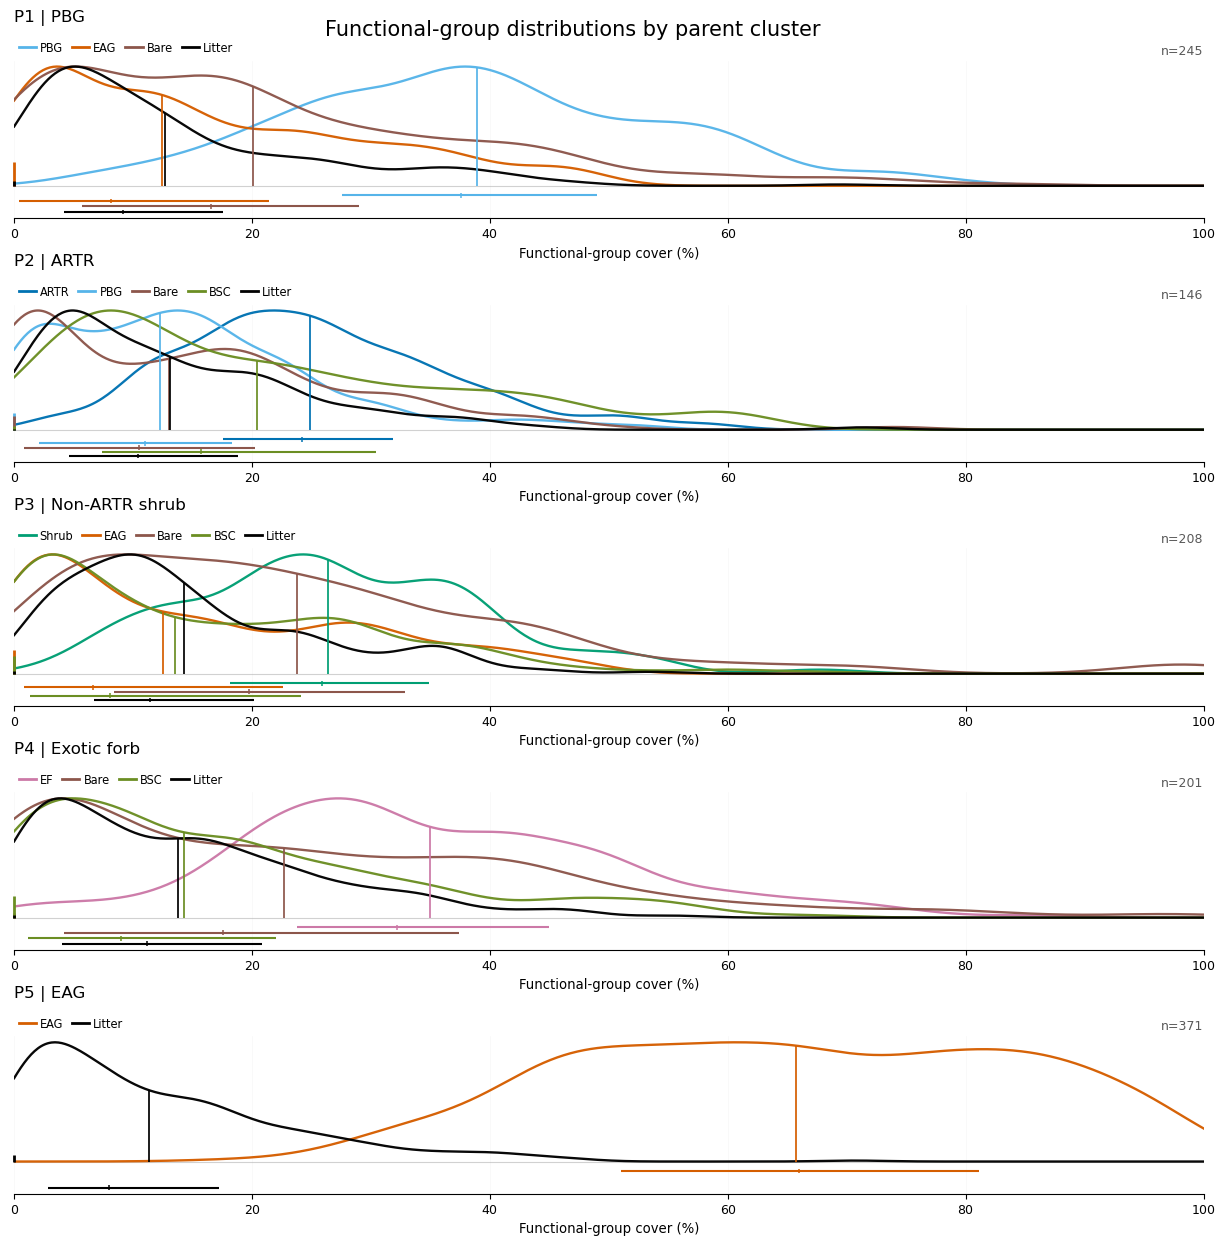

In [14]:
preview_overlaid_tufte_parent_densities_singlecol(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
)


In [15]:
# =============================================================================
# OVERLAID SINGLE-BASELINE TUFTE DENSITIES BY SUBCLUSTER / STATE
# SINGLE-COLUMN VERSION
# PREVIEW ONLY
# =============================================================================

from math import ceil
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D


def preview_overlaid_tufte_state_densities_singlecol(
    data,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=None,
    state_type_col="state_type",
    exclude_nonvegetated=True,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    ncols=1,
    bw_method=0.25,
    show_iqr=True,
    show_zero_ticks=True,
    panel_width=13,
    panel_height=2.10,
):

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "BSC",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Updated palette with better separation for Bare vs BSC
    fg_colors = {
        "ARTR_FG": "#0072B2",        # blue
        "SHRUB_FG": "#009E73",       # green
        "PBG_FG": "#56B4E9",         # sky blue
        "EAG_FG": "#D55E00",         # vermillion
        "EF_FG": "#CC79A7",          # magenta
        "BAREGROUND_FG": "#8C564B",  # brown
        "BIOCRUST_FG": "#6B8E23",    # olive
        "LITTER_FG": "#000000",      # black
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    plot_data = data.copy()

    if exclude_nonvegetated and state_type_col in plot_data.columns:
        plot_data = plot_data.loc[
            plot_data[state_type_col] == "vegetation_state"
        ].copy()

    def state_sort_key(x):
        if pd.isna(x):
            return (999, 999)
        if x == "BG":
            return (999, 999)
        parts = str(x).split(".")
        if len(parts) == 2:
            return (int(parts[0]), int(parts[1]))
        return (999, 999)

    states = sorted(
        plot_data[cluster_col].dropna().unique(),
        key=state_sort_key
    )

    n_panels = len(states)
    nrows = ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width, panel_height * nrows + 1.0),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()
    xx = np.linspace(0.01, x_max, 700)

    for ax, state in zip(axes, states):

        d = plot_data.loc[
            plot_data[cluster_col] == state
        ].copy()

        state_name = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n_state = len(d)

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # Shared baseline
        ax.axhline(
            0,
            color="0.82",
            linewidth=0.8,
            zorder=0
        )

        if show_iqr:
            iqr_offsets = np.linspace(
                -0.08,
                -0.22,
                len(keep_fgs)
            )

        legend_handles = []

        for i, fg in enumerate(keep_fgs):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]
            positive = x[x > 0]

            ridge_drawn = False
            yy_scaled = None

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):
                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):
                        yy_scaled = yy_raw / yy_raw.max()

                        ax.plot(
                            xx,
                            yy_scaled,
                            color=color,
                            linewidth=1.7,
                            alpha=0.97,
                            zorder=3,
                        )

                        ridge_drawn = True

                except np.linalg.LinAlgError:
                    pass

            mean_x = float(np.mean(x))

            if ridge_drawn:
                mean_top = float(
                    np.interp(mean_x, xx, yy_scaled)
                )
            else:
                mean_top = 0.15

            ax.vlines(
                mean_x,
                0,
                mean_top,
                color=color,
                linewidth=1.25,
                zorder=4,
            )

            if show_zero_ticks:
                zero_fraction = np.mean(x == 0)
                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        0,
                        min(zero_fraction, 0.20),
                        color=color,
                        linewidth=2.0,
                        zorder=5,
                        clip_on=False,
                    )

            if show_iqr:
                q25, median, q75 = np.quantile(
                    x,
                    [0.25, 0.50, 0.75]
                )

                y_iqr = iqr_offsets[i]

                ax.hlines(
                    y_iqr,
                    q25,
                    q75,
                    color=color,
                    linewidth=1.5,
                    zorder=4,
                )

                ax.vlines(
                    median,
                    y_iqr - 0.020,
                    y_iqr + 0.020,
                    color=color,
                    linewidth=1.1,
                    zorder=4,
                )

            legend_handles.append(
                Line2D(
                    [0], [0],
                    color=color,
                    lw=2,
                    label=fg_pretty[fg],
                )
            )

        ax.set_xlim(0, x_max)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(int(t)) for t in x_ticks])
        ax.tick_params(axis="x", labelbottom=True, labelsize=9)

        ax.set_ylim(-0.27, 1.05)
        ax.set_yticks([])

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9.5,
        )

        ax.set_title(
            f"S{state} | {state_name}",
            loc="left",
            fontsize=11.5,
            pad=24,
        )

        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.01),
            borderaxespad=0,
            ncol=len(legend_handles),
            fontsize=7.8,
            handlelength=1.4,
            handletextpad=0.32,
            columnspacing=0.75,
        )

        ax.text(
            1.0,
            1.02,
            f"n={n_state}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8.8,
            color="0.35",
            clip_on=False,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.45,
            alpha=0.12,
        )

    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        "Functional-group distributions by vegetation state",
        fontsize=15,
        y=0.998,
    )

    fig.subplots_adjust(
        top=0.985,
        bottom=0.03,
        left=0.08,
        right=0.985,
        hspace=0.48,
    )

    plt.show()


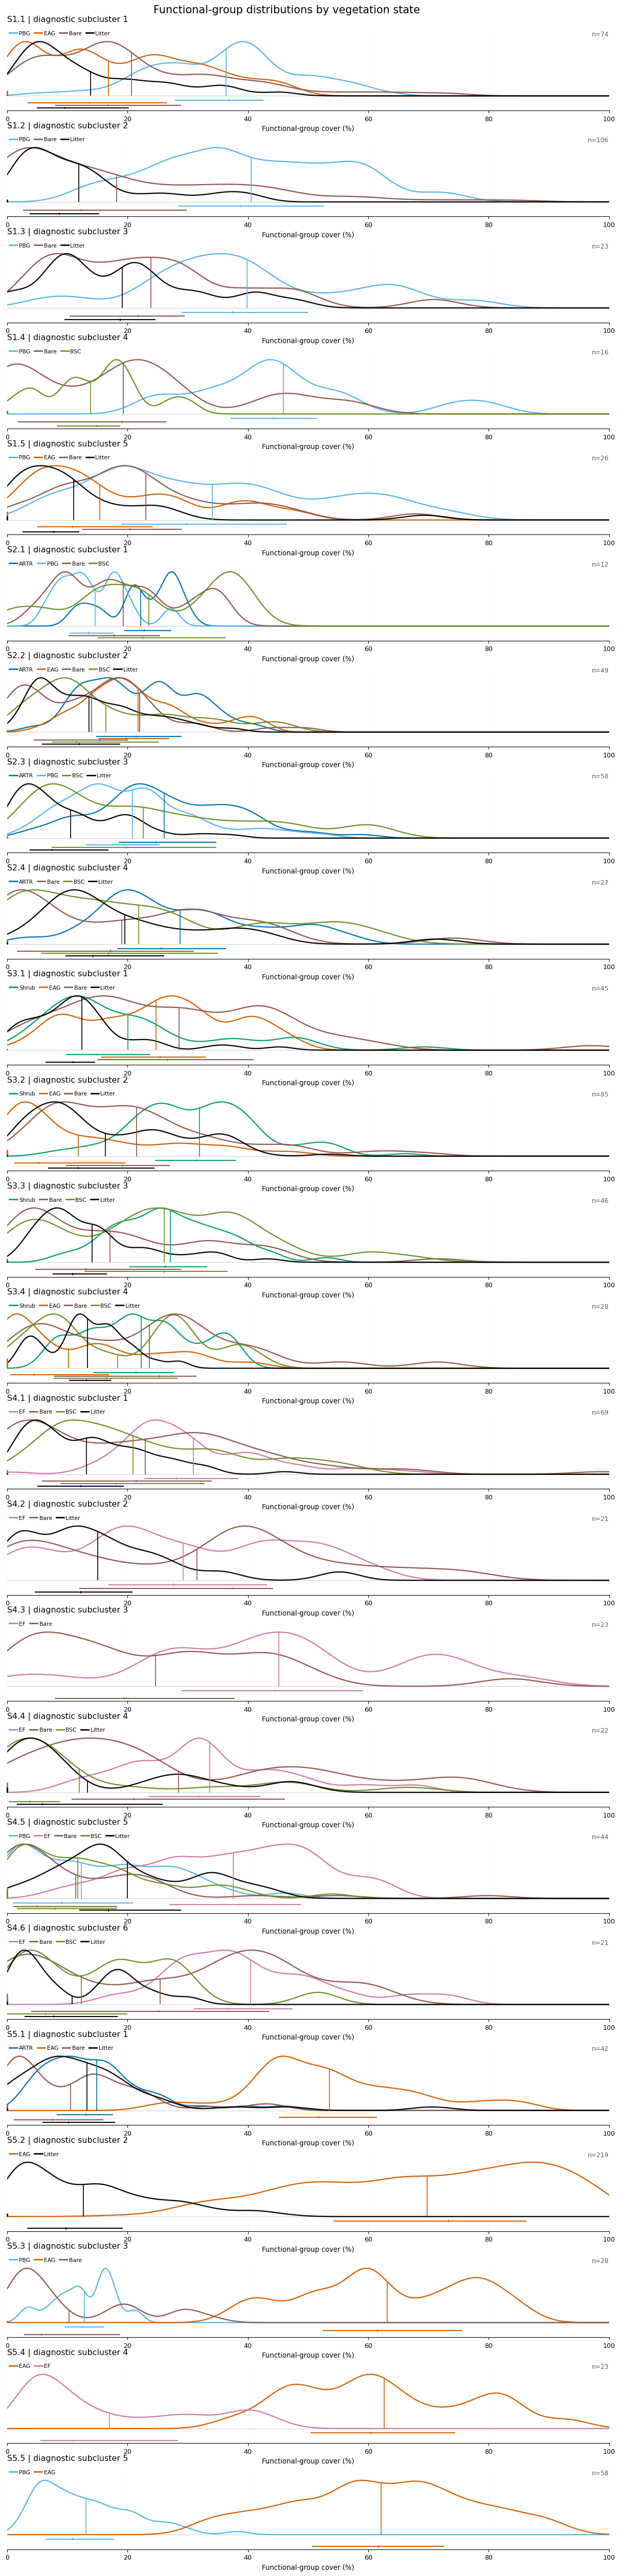

In [16]:
preview_overlaid_tufte_state_densities_singlecol(
    data=veg_states,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=FG_ALL,
    exclude_nonvegetated=True,
    mean_threshold=10.0,
    bw_method=0.25,
)


In [17]:
# =============================================================================
# PREVIEW ONLY: IQR-CLIPPED HALF-EYE FG DISTRIBUTIONS
# SINGLE-COLUMN, NARROWER VERSION
# Solid line = mean
# Dashed line = median
# Shrub = olive, BSC = green
# NO EXPORT
# =============================================================================

from scipy.stats import gaussian_kde
from matplotlib.patches import Patch


def preview_halfeye_iqr_singlecol(
    data,
    cluster_col,
    label_col,
    fg_cols=None,
    mean_threshold=10.0,
    x_max=100,
    x_ticks=np.arange(0, 101, 20),
    bw_method=0.25,
    show_zero_ticks=True,
    zero_tick_scale=0.18,
    panel_width=10.0,
    panel_height=1.85,
    title="Functional-group distributions",
    sort_key=None,
):
    """
    Draw compact half-eye panels:
      - one panel per cluster/state
      - one half-eye per retained FG
      - density clipped to the IQR [q25, q75]
      - solid vertical line = mean
      - dashed vertical line = median
      - optional zero-mass tick at x = 0
    """

    if fg_cols is None:
        fg_cols = FG_ALL

    fg_pretty = {
        "ARTR_FG": "ARTR",
        "SHRUB_FG": "Shrub",
        "PBG_FG": "PBG",
        "EAG_FG": "EAG",
        "EF_FG": "EF",
        "BAREGROUND_FG": "Bare",
        "BIOCRUST_FG": "BSC",
        "LITTER_FG": "Litter",
        "OTHER_FG": "Other",
        "NPF_FG": "NPF",
    }

    # Updated palette
    fg_colors = {
        "ARTR_FG": "#0072B2",        # blue
        "SHRUB_FG": "#6B8E23",       # olive
        "PBG_FG": "#56B4E9",         # sky blue
        "EAG_FG": "#D55E00",         # vermillion
        "EF_FG": "#CC79A7",          # reddish purple
        "BAREGROUND_FG": "#8C564B",  # brown
        "BIOCRUST_FG": "#009E73",    # green
        "LITTER_FG": "#000000",      # black
        "OTHER_FG": "#666666",
        "NPF_FG": "#444444",
    }

    ids = list(
        data[cluster_col]
        .dropna()
        .unique()
    )

    if sort_key is not None:
        ids = sorted(ids, key=sort_key)
    else:
        ids = sorted(ids)

    n_panels = len(ids)

    fig, axes = plt.subplots(
        nrows=n_panels,
        ncols=1,
        figsize=(
            panel_width,
            panel_height * n_panels + 0.8
        ),
        sharex=True,
        sharey=False,
    )

    axes = np.atleast_1d(axes).ravel()

    xx = np.linspace(
        0.001,
        x_max,
        800
    )

    for ax, gid in zip(axes, ids):

        d = data.loc[
            data[cluster_col] == gid
        ].copy()

        n_group = len(d)

        group_label = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        # -------------------------------------------------------------
        # Select FGs for display only
        # -------------------------------------------------------------

        fg_means = (
            d[fg_cols]
            .apply(pd.to_numeric, errors="coerce")
            .mean()
        )

        if mean_threshold is None:
            keep_fgs = list(fg_cols)
        else:
            keep_fgs = [
                fg for fg in fg_cols
                if fg_means[fg] > mean_threshold
            ]

        if len(keep_fgs) == 0:
            keep_fgs = [fg_means.idxmax()]

        # -------------------------------------------------------------
        # Vertical layout within each panel
        # -------------------------------------------------------------

        n_show = len(keep_fgs)

        y_positions = (
            np.arange(n_show, 0, -1)
            * 1.0
        )

        # -------------------------------------------------------------
        # Functional-group half-eyes
        # -------------------------------------------------------------

        legend_handles = []

        for fg, y0 in zip(
            keep_fgs,
            y_positions
        ):

            x = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(x) == 0:
                continue

            color = fg_colors[fg]

            # baseline
            ax.hlines(
                y0,
                0,
                x_max,
                color="0.84",
                linewidth=0.7,
                zorder=0,
            )

            # direct FG label
            ax.text(
                -1.8,
                y0,
                fg_pretty[fg],
                ha="right",
                va="center",
                fontsize=9.5,
                color=color,
                clip_on=False,
            )

            # zero mass
            if show_zero_ticks:
                zero_fraction = np.mean(x == 0)

                if zero_fraction > 0:
                    ax.vlines(
                        0,
                        y0,
                        y0 + min(
                            zero_fraction,
                            zero_tick_scale
                        ),
                        color=color,
                        linewidth=2.0,
                        zorder=4,
                        clip_on=False,
                    )

            positive = x[x > 0]

            # ---------------------------------------------------------
            # Summary statistics from complete observed distribution
            # ---------------------------------------------------------

            q25, median, q75 = np.quantile(
                x,
                [0.25, 0.50, 0.75]
            )

            mean_x = float(np.mean(x))

            # ---------------------------------------------------------
            # KDE over positive-cover observations
            # ---------------------------------------------------------

            if (
                len(positive) >= 5
                and len(np.unique(positive)) >= 3
            ):

                try:
                    kde = gaussian_kde(
                        positive,
                        bw_method=bw_method
                    )

                    yy_raw = kde(xx)

                    if (
                        np.isfinite(yy_raw).all()
                        and yy_raw.max() > 0
                    ):

                        yy = (
                            yy_raw
                            / yy_raw.max()
                        )

                        # ---------------------------------------------
                        # Clip half-eye horizontally to observed IQR
                        # ---------------------------------------------

                        mask = (
                            (xx >= q25)
                            & (xx <= q75)
                        )

                        xx_clip = xx[mask]
                        yy_clip = yy[mask]

                        if len(xx_clip) > 1:

                            ax.fill_between(
                                xx_clip,
                                y0,
                                y0 + yy_clip,
                                facecolor=color,
                                edgecolor="none",
                                alpha=0.22,
                                zorder=2,
                            )

                            ax.plot(
                                xx_clip,
                                y0 + yy_clip,
                                color=color,
                                linewidth=1.35,
                                zorder=3,
                            )

                            # -----------------------------------------
                            # Mean = solid
                            # Median = dashed
                            # -----------------------------------------

                            def height_at(x0):
                                if (
                                    x0 < q25
                                    or x0 > q75
                                ):
                                    return 0.35

                                return float(
                                    np.interp(
                                        x0,
                                        xx_clip,
                                        yy_clip
                                    )
                                )

                            mean_h = height_at(mean_x)
                            median_h = height_at(median)

                            ax.vlines(
                                mean_x,
                                y0,
                                y0 + mean_h,
                                color=color,
                                linewidth=1.45,
                                linestyle="-",
                                zorder=5,
                            )

                            ax.vlines(
                                median,
                                y0,
                                y0 + median_h,
                                color=color,
                                linewidth=1.35,
                                linestyle="--",
                                zorder=5,
                            )

                except np.linalg.LinAlgError:
                    pass

            else:
                # -----------------------------------------------------
                # Fallback when KDE is poorly supported
                # -----------------------------------------------------

                ax.hlines(
                    y0,
                    q25,
                    q75,
                    color=color,
                    linewidth=5,
                    alpha=0.22,
                    zorder=2,
                )

                ax.vlines(
                    mean_x,
                    y0,
                    y0 + 0.35,
                    color=color,
                    linewidth=1.45,
                    linestyle="-",
                    zorder=5,
                )

                ax.vlines(
                    median,
                    y0,
                    y0 + 0.35,
                    color=color,
                    linewidth=1.35,
                    linestyle="--",
                    zorder=5,
                )

            legend_handles.append(
                Patch(
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.22,
                    label=fg_pretty[fg],
                )
            )

        # -------------------------------------------------------------
        # Panel formatting
        # -------------------------------------------------------------

        ax.set_xlim(
            0,
            x_max
        )

        ax.set_xticks(
            x_ticks
        )

        ax.set_xticklabels(
            [
                str(int(v))
                for v in x_ticks
            ],
            fontsize=8.5,
        )

        ax.tick_params(
            axis="x",
            labelbottom=True
        )

        ax.set_ylim(
            0.65,
            y_positions.max() + 1.05
        )

        ax.set_yticks([])

        ax.set_title(
            f"{gid} | {group_label}",
            loc="left",
            fontsize=11.5,
            pad=18,
        )

        ax.text(
            1.0,
            1.02,
            f"n={n_group}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8.8,
            color="0.35",
            clip_on=False,
        )

        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="lower left",
            bbox_to_anchor=(0.0, 1.01),
            borderaxespad=0,
            ncol=min(
                len(legend_handles),
                5
            ),
            fontsize=7.8,
            handlelength=1.25,
            handletextpad=0.30,
            columnspacing=0.70,
        )

        ax.set_xlabel(
            "Functional-group cover (%)",
            fontsize=9,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        ax.grid(
            axis="x",
            linewidth=0.40,
            alpha=0.12,
        )

    # -------------------------------------------------------------
    # Figure formatting
    # -------------------------------------------------------------

    fig.suptitle(
        title,
        fontsize=14,
        y=0.998,
    )

    fig.subplots_adjust(
        top=0.985,
        bottom=0.03,
        left=0.11,
        right=0.98,
        hspace=0.52,
    )

    # PREVIEW ONLY
    plt.show()


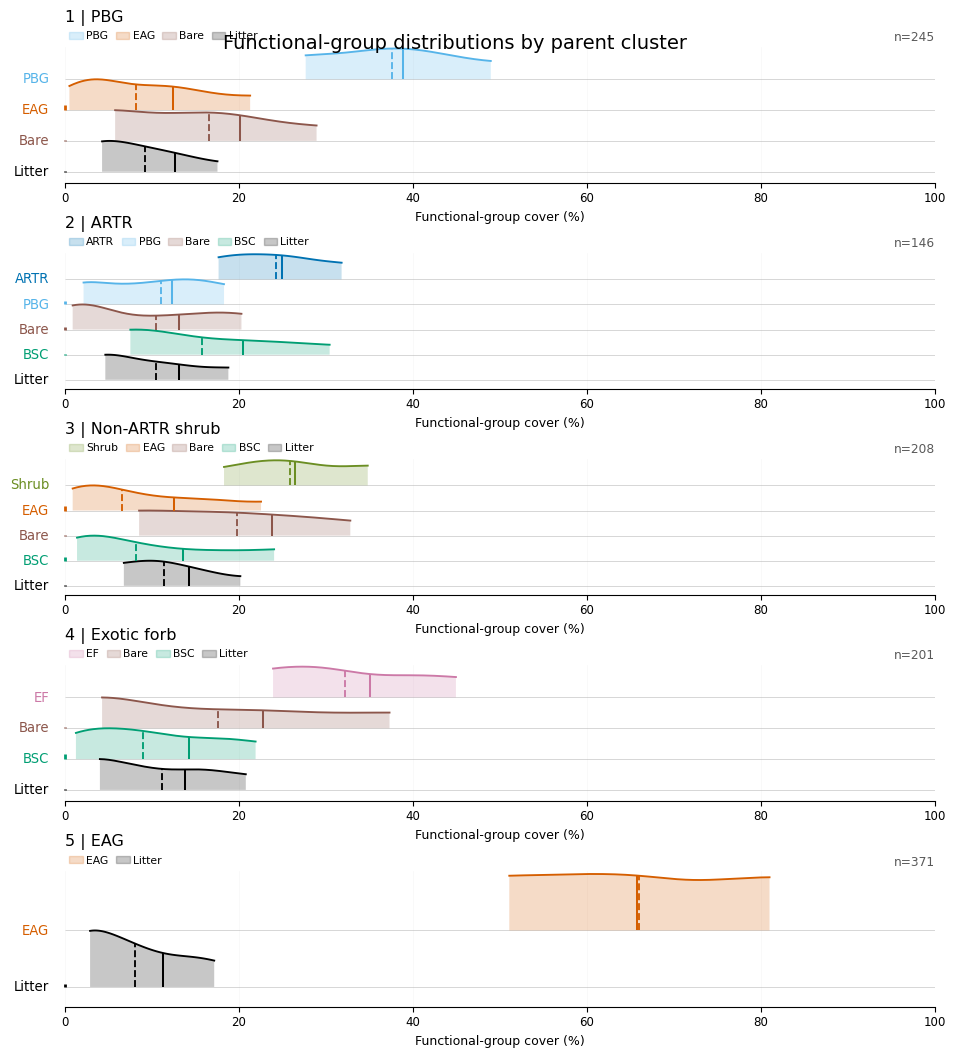

In [18]:
preview_halfeye_iqr_singlecol(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.25,
    panel_width=10.0,
    panel_height=1.85,
    title="Functional-group distributions by parent cluster",
)


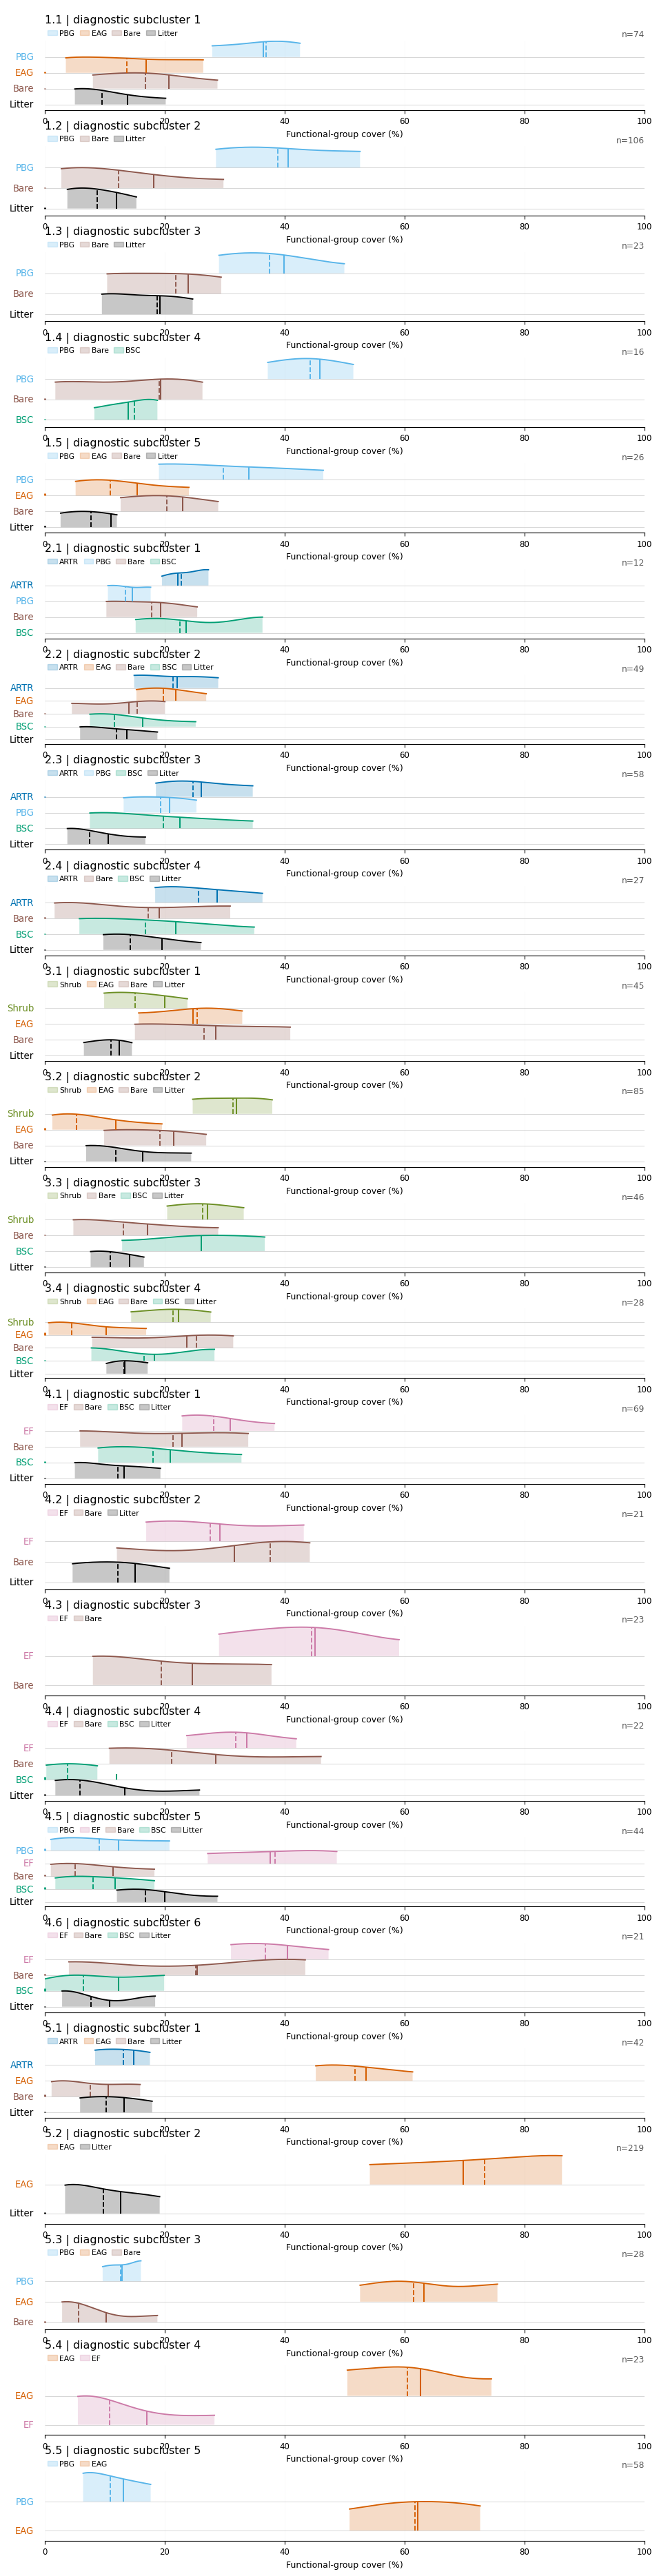

In [19]:
# =============================================================================
# PREVIEW ONLY: IQR-CLIPPED HALF-EYE FG DISTRIBUTIONS
# K5 DIAGNOSTIC SPECIES SUBCLUSTERS
# Solid line = mean
# Dashed line = median
# BG excluded
# NO EXPORT
# =============================================================================

def state_sort_key(x):
    if pd.isna(x):
        return (999, 999)

    x = str(x)

    if x == "BG":
        return (999, 999)

    parent, sub = x.split(".")
    return (int(parent), int(sub))


veg_states_plot = veg_states.loc[
    veg_states["state_type"] == "vegetation_state"
].copy()


preview_halfeye_iqr_singlecol(
    data=veg_states_plot,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=FG_ALL,
    mean_threshold=10.0,
    bw_method=0.4,
    panel_width=10.0,
    panel_height=1.55,
    title=" ",
    sort_key=state_sort_key,
)


In [ ]:
# =============================================================================
# PREVIEW ONLY: MONDRIAN COMPOSITION PANELS
#
# Rectangle area = mean FG cover
# White area     = all FG means not displayed (>10% threshold not met)
# Hue            = FG identity only
# Dark inset     = IQR (Q25-Q75)
# Dashed tick    = median
#
# NO EXPORT
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgb


# -----------------------------------------------------------------------------
# Visual definitions
# -----------------------------------------------------------------------------

MONDRIAN_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS_MONDRIAN = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "BSC",
    "LITTER_FG": "Litter",
}

FG_COLORS_MONDRIAN = {
    "ARTR_FG": "#0072B2",        # blue
    "SHRUB_FG": "#6B8E23",       # olive
    "PBG_FG": "#56B4E9",         # sky blue
    "EAG_FG": "#D55E00",         # vermillion
    "EF_FG": "#CC79A7",          # magenta
    "BAREGROUND_FG": "#8C564B",  # brown
    "BIOCRUST_FG": "#009E73",    # green
    "LITTER_FG": "#000000",      # black
}


def blend_with_white(color, amount=0.25):
    rgb = np.array(to_rgb(color))
    return tuple(
        rgb * (1 - amount)
        + np.ones(3) * amount
    )


# -----------------------------------------------------------------------------
# Recursive Mondrian / guillotine partition
# -----------------------------------------------------------------------------

def mondrian_partition(items, x, y, w, h, vertical=True):
    """
    Recursively divide a rectangle.

    items:
        list of dictionaries containing:
        {"name": ..., "weight": ...}

    Rectangle AREA is proportional to weight.
    """

    if len(items) == 1:
        item = items[0].copy()
        item.update({
            "x": x,
            "y": y,
            "w": w,
            "h": h,
        })
        return [item]

    total = sum(item["weight"] for item in items)

    # Find the split closest to half the total weight
    cumulative = np.cumsum([
        item["weight"]
        for item in items
    ])

    split_idx = np.argmin(
        np.abs(cumulative - total / 2)
    ) + 1

    # Prevent an empty side
    split_idx = min(
        max(split_idx, 1),
        len(items) - 1
    )

    left_items = items[:split_idx]
    right_items = items[split_idx:]

    left_weight = sum(
        item["weight"]
        for item in left_items
    )

    fraction = left_weight / total

    if vertical:

        w1 = w * fraction
        w2 = w - w1

        return (
            mondrian_partition(
                left_items,
                x,
                y,
                w1,
                h,
                vertical=False,
            )
            +
            mondrian_partition(
                right_items,
                x + w1,
                y,
                w2,
                h,
                vertical=False,
            )
        )

    else:

        h1 = h * fraction
        h2 = h - h1

        return (
            mondrian_partition(
                left_items,
                x,
                y,
                w,
                h1,
                vertical=True,
            )
            +
            mondrian_partition(
                right_items,
                x,
                y + h1,
                w,
                h2,
                vertical=True,
            )
        )


# -----------------------------------------------------------------------------
# Main plotting function
# -----------------------------------------------------------------------------

def preview_mondrian_clusters(
    data,
    cluster_col,
    label_col,
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    sort_key=None,
    ncols=2,
    panel_size=4.6,
    title="Functional-group composition",
):

    cluster_ids = list(
        data[cluster_col]
        .dropna()
        .unique()
    )

    if sort_key is not None:
        cluster_ids = sorted(
            cluster_ids,
            key=sort_key
        )
    else:
        cluster_ids = sorted(cluster_ids)

    n_panels = len(cluster_ids)
    nrows = int(
        np.ceil(n_panels / ncols)
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            panel_size * ncols,
            panel_size * nrows
        )
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for ax, cluster_id in zip(
        axes,
        cluster_ids
    ):

        d = data.loc[
            data[cluster_col]
            == cluster_id
        ].copy()

        label = (
            d[label_col]
            .dropna()
            .iloc[0]
        )

        n = len(d)

        # -------------------------------------------------------------
        # Calculate FG statistics
        # -------------------------------------------------------------

        stats = {}

        for fg in fg_cols:

            values = (
                pd.to_numeric(
                    d[fg],
                    errors="coerce"
                )
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(values) == 0:
                continue

            stats[fg] = {
                "mean": float(
                    np.mean(values)
                ),
                "median": float(
                    np.median(values)
                ),
                "q25": float(
                    np.quantile(
                        values,
                        0.25
                    )
                ),
                "q75": float(
                    np.quantile(
                        values,
                        0.75
                    )
                ),
            }

        # -------------------------------------------------------------
        # Only major structural FGs receive colored area
        # -------------------------------------------------------------

        retained = [
            fg
            for fg in fg_cols
            if (
                fg in stats
                and stats[fg]["mean"]
                > mean_threshold
            )
        ]

        retained_total = sum(
            stats[fg]["mean"]
            for fg in retained
        )

        # Anything not represented by a >10% FG stays white.
        white_weight = max(
            0.0,
            100.0 - retained_total
        )

        items = [
            {
                "name": fg,
                "weight": stats[fg]["mean"],
            }
            for fg in retained
        ]

        if white_weight > 0:
            items.append({
                "name": "__WHITE__",
                "weight": white_weight,
            })

        # Keep ecological FG order rather than sorting by magnitude.
        # This makes corresponding colors more spatially stable.
        tiles = mondrian_partition(
            items,
            x=0,
            y=0,
            w=1,
            h=1,
            vertical=True,
        )

        # -------------------------------------------------------------
        # Draw Mondrian geometry
        # -------------------------------------------------------------

        for tile in tiles:

            name = tile["name"]

            x0 = tile["x"]
            y0 = tile["y"]
            w = tile["w"]
            h = tile["h"]

            if name == "__WHITE__":

                ax.add_patch(
                    Rectangle(
                        (x0, y0),
                        w,
                        h,
                        facecolor="white",
                        edgecolor="black",
                        linewidth=2.2,
                    )
                )

                continue

            color = FG_COLORS_MONDRIAN[name]
            s = stats[name]

            # ---------------------------------------------------------
            # Primary rectangle
            #
            # AREA = mean cover
            # ---------------------------------------------------------

            ax.add_patch(
                Rectangle(
                    (x0, y0),
                    w,
                    h,
                    facecolor=blend_with_white(
                        color,
                        0.18
                    ),
                    edgecolor="black",
                    linewidth=2.2,
                    zorder=1,
                )
            )

            # ---------------------------------------------------------
            # Distribution ruler inside bottom of each tile
            #
            # Position is on a LOCAL 0-100% scale.
            # Dark segment = IQR.
            # Dashed tick = median.
            # ---------------------------------------------------------

            pad_x = w * 0.08

            ruler_x0 = x0 + pad_x
            ruler_w = w - 2 * pad_x

            # only draw if tile is large enough
            if w > 0.08 and h > 0.08:

                ruler_y = y0 + h * 0.10
                ruler_h = max(
                    h * 0.09,
                    0.012
                )

                # faint full 0-100 track
                ax.add_patch(
                    Rectangle(
                        (
                            ruler_x0,
                            ruler_y
                        ),
                        ruler_w,
                        ruler_h,
                        facecolor=blend_with_white(
                            color,
                            0.60
                        ),
                        edgecolor="none",
                        zorder=2,
                    )
                )

                # IQR segment
                q25_x = (
                    ruler_x0
                    + ruler_w
                    * s["q25"] / 100
                )

                q75_x = (
                    ruler_x0
                    + ruler_w
                    * s["q75"] / 100
                )

                ax.add_patch(
                    Rectangle(
                        (
                            q25_x,
                            ruler_y
                        ),
                        max(
                            q75_x - q25_x,
                            0.002
                        ),
                        ruler_h,
                        facecolor=color,
                        edgecolor="none",
                        zorder=3,
                    )
                )

                # Median
                median_x = (
                    ruler_x0
                    + ruler_w
                    * s["median"] / 100
                )

                ax.vlines(
                    median_x,
                    ruler_y - ruler_h * 0.25,
                    ruler_y + ruler_h * 1.25,
                    color="black",
                    linewidth=1.1,
                    linestyle="--",
                    zorder=4,
                )

            # ---------------------------------------------------------
            # FG label + mean
            # ---------------------------------------------------------

            area = w * h

            if area > 0.055:

                ax.text(
                    x0 + w / 2,
                    y0 + h / 2,
                    (
                        f"{FG_LABELS_MONDRIAN[name]}\n"
                        f"{s['mean']:.0f}%"
                    ),
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=(
                        "white"
                        if name == "LITTER_FG"
                        else "black"
                    ),
                    zorder=5,
                )

        # -------------------------------------------------------------
        # Panel formatting
        # -------------------------------------------------------------

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_title(
            f"{cluster_id} | {label}",
            loc="left",
            fontsize=11,
            pad=8,
        )

        ax.text(
            1.0,
            1.015,
            f"n={n}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8.5,
            color="0.35",
        )

    # hide unused panels
    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(
        title,
        fontsize=15,
        y=0.995,
    )

    fig.subplots_adjust(
        top=0.95,
        bottom=0.03,
        left=0.04,
        right=0.98,
        hspace=0.28,
        wspace=0.20,
    )

    plt.show()


In [ ]:
preview_mondrian_clusters(
    data=veg_parent,
    cluster_col="parent_cluster",
    label_col="parent_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    ncols=2,
    panel_size=4.6,
    title="Functional-group structure of parent clusters",
)


In [ ]:
# =============================================================================
# PREVIEW ONLY: MONDRIAN COMPOSITION PANELS
# K5 DIAGNOSTIC SPECIES SUBCLUSTERS
#
# Rectangle area = mean FG cover
# White area     = FGs omitted by >10% display threshold
# Hue            = FG identity
# Dark inset     = IQR
# Dashed tick    = median
#
# BG excluded
# NO EXPORT
# =============================================================================

def state_sort_key(x):
    if pd.isna(x):
        return (999, 999)

    x = str(x)

    if x == "BG":
        return (999, 999)

    parent, sub = x.split(".")
    return (int(parent), int(sub))


veg_states_plot = veg_states.loc[
    veg_states["state_type"] == "vegetation_state"
].copy()


preview_mondrian_clusters(
    data=veg_states_plot,
    cluster_col="state_id",
    label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    sort_key=state_sort_key,
    ncols=3,
    panel_size=3.8,
    title="Functional-group structure of vegetation states",
)


In [ ]:
# =============================================================================
# HIERARCHICAL MONDRIAN ATLAS — CLEAN LAYOUT VERSION
#
# Fixes:
# - removes legend
# - removes median/IQR marks inside tiles
# - wraps long child titles
# - improves margins and spacing
# - keeps one large parent panel + smaller child panels on same row
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
import textwrap


# -----------------------------------------------------------------------------
# Display definitions
# -----------------------------------------------------------------------------

MONDRIAN_FGS = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
]

FG_LABELS_MONDRIAN = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "BSC",
    "LITTER_FG": "Litter",
}

# Okabe-Ito derived / high contrast set
FG_COLORS_MONDRIAN = {
    "ARTR_FG": "#0072B2",        # blue
    "SHRUB_FG": "#6B8E23",       # olive green
    "PBG_FG": "#56B4E9",         # sky blue
    "EAG_FG": "#D55E00",         # vermillion
    "EF_FG": "#CC79A7",          # reddish purple
    "BAREGROUND_FG": "#8C564B",  # brown
    "BIOCRUST_FG": "#009E73",    # bluish green
    "LITTER_FG": "#222222",      # near-black
}


def blend_with_white(color, amount=0.18):
    from matplotlib.colors import to_rgb
    rgb = np.array(to_rgb(color))
    return tuple(rgb * (1 - amount) + np.ones(3) * amount)


# -----------------------------------------------------------------------------
# Recursive Mondrian partition
# -----------------------------------------------------------------------------

def mondrian_partition(items, x, y, w, h, vertical=True):
    """
    Recursively partition a rectangle so area is proportional to item weight.
    """
    if len(items) == 1:
        item = items[0].copy()
        item.update({"x": x, "y": y, "w": w, "h": h})
        return [item]

    total = sum(item["weight"] for item in items)
    cumulative = np.cumsum([item["weight"] for item in items])

    split_idx = np.argmin(np.abs(cumulative - total / 2)) + 1
    split_idx = min(max(split_idx, 1), len(items) - 1)

    first = items[:split_idx]
    second = items[split_idx:]

    first_weight = sum(item["weight"] for item in first)
    frac = first_weight / total if total > 0 else 0.5

    if vertical:
        w1 = w * frac
        return (
            mondrian_partition(first, x, y, w1, h, vertical=False)
            + mondrian_partition(second, x + w1, y, w - w1, h, vertical=False)
        )
    else:
        h1 = h * frac
        return (
            mondrian_partition(first, x, y, w, h1, vertical=True)
            + mondrian_partition(second, x, y + h1, w, h - h1, vertical=True)
        )


# -----------------------------------------------------------------------------
# Draw one Mondrian panel
# -----------------------------------------------------------------------------

def draw_mondrian_panel_clean(
    ax,
    data,
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    title="",
    n_value=None,
    child=False,
    title_wrap=None,
):
    if len(data) == 0:
        ax.axis("off")
        return

    # -------------------------------------------------------------------------
    # Summary stats
    # -------------------------------------------------------------------------
    stats = {}

    for fg in fg_cols:
        vals = (
            pd.to_numeric(data[fg], errors="coerce")
            .dropna()
            .to_numpy(dtype=float)
        )
        if len(vals) == 0:
            continue

        stats[fg] = {
            "mean": float(np.mean(vals)),
            "median": float(np.median(vals)),
            "q25": float(np.quantile(vals, 0.25)),
            "q75": float(np.quantile(vals, 0.75)),
        }

    retained = [
        fg for fg in fg_cols
        if fg in stats and stats[fg]["mean"] > mean_threshold
    ]

    retained_total = sum(stats[fg]["mean"] for fg in retained)
    white_weight = max(0.0, 100.0 - retained_total)

    items = [{"name": fg, "weight": stats[fg]["mean"]} for fg in retained]
    if white_weight > 0:
        items.append({"name": "__WHITE__", "weight": white_weight})

    # Sort large to small generally helps label placement/readability
    items = sorted(items, key=lambda d: d["weight"], reverse=True)

    tiles = mondrian_partition(items, x=0, y=0, w=1, h=1, vertical=True)

    # Styling
    border_width = 1.8 if not child else 1.15
    label_fs = 8.0 if not child else 6.2

    # -------------------------------------------------------------------------
    # Draw tiles
    # -------------------------------------------------------------------------
    for tile in tiles:
        name = tile["name"]
        x0, y0, w, h = tile["x"], tile["y"], tile["w"], tile["h"]

        if name == "__WHITE__":
            ax.add_patch(
                Rectangle(
                    (x0, y0), w, h,
                    facecolor="white",
                    edgecolor="black",
                    linewidth=border_width,
                )
            )
            continue

        face = blend_with_white(FG_COLORS_MONDRIAN[name], amount=0.15)

        ax.add_patch(
            Rectangle(
                (x0, y0), w, h,
                facecolor=face,
                edgecolor="black",
                linewidth=border_width,
            )
        )

        # Only label if there is enough room
        area = w * h
        min_area = 0.050 if not child else 0.080

        if area >= min_area:
            txt = f"{FG_LABELS_MONDRIAN[name]}\n{stats[name]['mean']:.0f}%"
            ax.text(
                x0 + w / 2,
                y0 + h / 2,
                txt,
                ha="center",
                va="center",
                fontsize=label_fs,
                color="white" if name == "LITTER_FG" else "black",
                linespacing=0.95,
                clip_on=False,
            )

    # -------------------------------------------------------------------------
    # Panel formatting
    # -------------------------------------------------------------------------
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Title wrapping
    title_text = title
    if title_wrap is not None:
        title_text = "\n".join(
            textwrap.wrap(title, width=title_wrap, break_long_words=False)
        )

    title_fs = 12 if not child else 7.6
    ax.set_title(
        title_text,
        loc="left",
        fontsize=title_fs,
        pad=6 if not child else 4,
    )

    # Separate n label
    if n_value is None:
        n_value = len(data)

    ax.text(
        1.0,
        1.03,
        f"n={n_value}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8 if not child else 6.4,
        color="0.35",
        clip_on=False,
    )


# -----------------------------------------------------------------------------
# Hierarchical figure
# -----------------------------------------------------------------------------

def preview_hierarchical_mondrian_clean(
    parent_data,
    state_data,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    suppress_singletons=True,
):
    """
    One row per parent cluster.
    Left: larger parent panel
    Right: smaller child state panels
    """

    state_plot = state_data.loc[
        state_data["state_type"] == "vegetation_state"
    ].copy()

    parents = sorted(parent_data[parent_col].dropna().unique())

    # Find maximum number of *displayed* child states in any parent
    child_lists = {}
    for p in parents:
        children = (
            state_plot.loc[state_plot["parent_cluster"] == p, state_col]
            .dropna()
            .unique()
            .tolist()
        )
        children = sorted(
            children,
            key=lambda s: tuple(int(v) for v in str(s).split("."))
        )

        if suppress_singletons and len(children) == 1:
            children = []

        child_lists[p] = children

    max_children = max(max(len(v), 1) for v in child_lists.values())

    nrows = len(parents)
    ncols = 1 + max_children

    # Wider page, slightly shorter height than previous version
    fig = plt.figure(figsize=(16, 21))
    gs = fig.add_gridspec(
        nrows=nrows,
        ncols=ncols,
        width_ratios=[1.25] + [0.85] * max_children,
        height_ratios=[1] * nrows,
        wspace=0.28,
        hspace=0.42,
    )

    for r, parent in enumerate(parents):
        parent_subset = parent_data.loc[parent_data[parent_col] == parent].copy()
        parent_label = parent_subset[parent_label_col].dropna().iloc[0]

        # Parent panel
        ax_parent = fig.add_subplot(gs[r, 0])
        draw_mondrian_panel_clean(
            ax_parent,
            parent_subset,
            fg_cols=fg_cols,
            mean_threshold=mean_threshold,
            title=f"P{int(parent)} | {parent_label}",
            n_value=len(parent_subset),
            child=False,
            title_wrap=32,
        )

        # Child panels
        children = child_lists[parent]

        for j in range(max_children):
            ax_child = fig.add_subplot(gs[r, j + 1])

            if j < len(children):
                sid = children[j]
                child_subset = state_plot.loc[state_plot[state_col] == sid].copy()
                child_label = child_subset[state_label_col].dropna().iloc[0]

                draw_mondrian_panel_clean(
                    ax_child,
                    child_subset,
                    fg_cols=fg_cols,
                    mean_threshold=mean_threshold,
                    title=f"{sid} | {child_label}",
                    n_value=len(child_subset),
                    child=True,
                    title_wrap=20,
                )
            else:
                ax_child.axis("off")

    fig.suptitle(
        "Hierarchical functional-group structure",
        fontsize=20,
        y=0.985,
    )

    fig.text(
        0.115, 0.967,
        "Parent cluster",
        ha="center",
        va="bottom",
        fontsize=10,
        color="0.35",
    )

    fig.text(
        0.57, 0.967,
        "Diagnostic species subclusters",
        ha="center",
        va="bottom",
        fontsize=10,
        color="0.35",
    )

    fig.text(
        0.5,
        0.012,
        f"Colored area = mean FG cover for components > {mean_threshold:.0f}%   |   white = remaining composition",
        ha="center",
        fontsize=8.5,
        color="0.35",
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.985,
        top=0.955,
        bottom=0.03,
    )

    plt.show()


In [ ]:
preview_hierarchical_mondrian_clean(
    parent_data=veg_parent,
    state_data=veg_states,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    suppress_singletons=True,
)


In [ ]:
# =============================================================================
# PREVIEW ONLY: HIERARCHICAL MONDRIAN STRUCTURE
# - parent label rotated 90° on the left side of each parent square
# - n= placed beneath bottom-right corner of EVERY square
# - children kept compact and aligned
# - NO EXPORT
# =============================================================================

import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle


def draw_mondrian_panel_clean(
    ax,
    data,
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    show_fg_names=True,
    tile_fontsize=8.0,
    border_width=1.1,
):
    """Draw a Mondrian-like panel using mean FG cover > threshold."""
    if len(data) == 0:
        ax.axis("off")
        return

    means = {}
    for fg in fg_cols:
        vals = pd.to_numeric(data[fg], errors="coerce").dropna().to_numpy(dtype=float)
        if len(vals):
            means[fg] = float(np.mean(vals))

    retained = [fg for fg in fg_cols if fg in means and means[fg] > mean_threshold]
    retained_total = sum(means[fg] for fg in retained)
    white_weight = max(0.0, 100.0 - retained_total)

    items = [{"name": fg, "weight": means[fg]} for fg in retained]
    if white_weight > 0:
        items.append({"name": "__WHITE__", "weight": white_weight})

    items = sorted(items, key=lambda x: x["weight"], reverse=True)

    tiles = mondrian_partition(
        items,
        x=0,
        y=0,
        w=1,
        h=1,
        vertical=True,
    )

    for tile in tiles:
        name = tile["name"]
        x0, y0, w, h = tile["x"], tile["y"], tile["w"], tile["h"]

        if name == "__WHITE__":
            face = "white"
        else:
            face = blend_with_white(FG_COLORS_MONDRIAN[name], amount=0.10)

        ax.add_patch(
            Rectangle(
                (x0, y0),
                w,
                h,
                facecolor=face,
                edgecolor="black",
                linewidth=border_width,
            )
        )

        if name == "__WHITE__":
            continue

        area = w * h
        min_area = 0.055 if show_fg_names else 0.07
        if area < min_area:
            continue

        if show_fg_names:
            txt = f"{FG_LABELS_MONDRIAN[name]}\n{means[name]:.0f}%"
        else:
            txt = f"{means[name]:.0f}%"

        ax.text(
            x0 + w / 2,
            y0 + h / 2,
            txt,
            ha="center",
            va="center",
            fontsize=tile_fontsize,
            linespacing=0.90,
            color="white" if name == "LITTER_FG" else "black",
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_visible(False)


def preview_hierarchical_mondrian_rotated_parent_labels(
    parent_data,
    state_data,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=10.0,
    suppress_singletons=True,
    figure_width=7.6,
    parent_size=1.30,
    child_scale=0.52,
    parent_child_gap=0.28,
    child_gap=0.14,
    row_gap=0.34,
    label_gutter=0.34,
):
    """
    Parent panels in first column.
    Children aligned to a fixed global child grid.
    Parent labels rotated 90° and placed left of parent square.
    n labels placed below bottom-right of each square.
    """

    state_plot = state_data.loc[state_data["state_type"] == "vegetation_state"].copy()

    parents = sorted(parent_data[parent_col].dropna().unique())

    child_lists = {}
    for parent in parents:
        children = (
            state_plot.loc[state_plot[parent_col] == parent, state_col]
            .dropna()
            .unique()
            .tolist()
        )
        children = sorted(
            children,
            key=lambda s: tuple(int(v) for v in str(s).split("."))
        )
        if suppress_singletons and len(children) == 1:
            children = []
        child_lists[parent] = children

    max_children = max(len(v) for v in child_lists.values()) if child_lists else 0

    child_size = parent_size * child_scale

    # Compact but readable figure geometry in inches
    header_h = 0.55
    footer_h = 0.30
    row_h = max(parent_size, child_size + 0.22) + row_gap
    fig_h = header_h + len(parents) * row_h + footer_h

    fig = plt.figure(figsize=(figure_width, fig_h))

    # Physical positions (inches)
    left_margin = 0.20
    top_margin = 0.42
    bottom_margin = 0.28

    parent_x = left_margin + label_gutter
    child_start_x = parent_x + parent_size + parent_child_gap

    # Title
    fig.suptitle(
        " ",
        fontsize=16,
        y=0.992,
    )
    fig.text(
        0.74,
        0.975,
        " ",
        ha="center",
        va="center",
        fontsize=10,
        color="0.4",
    )

    for row_i, parent in enumerate(parents):
        row_top = top_margin + row_i * row_h
        parent_bottom = fig_h - row_top - parent_size

        parent_subset = parent_data.loc[parent_data[parent_col] == parent].copy()
        parent_label = parent_subset[parent_label_col].dropna().iloc[0]

        # ---------------------------------------------------------------------
        # Parent axis
        # ---------------------------------------------------------------------
        ax_parent = fig.add_axes([
            parent_x / figure_width,
            parent_bottom / fig_h,
            parent_size / figure_width,
            parent_size / fig_h,
        ])

        draw_mondrian_panel_clean(
            ax=ax_parent,
            data=parent_subset,
            fg_cols=fg_cols,
            mean_threshold=mean_threshold,
            show_fg_names=True,
            tile_fontsize=8.0,
            border_width=1.15,
        )

        # Rotated parent label on left side
        parent_text = f"P{int(parent)} | {parent_label}"
        parent_text = "\n".join(
            textwrap.wrap(parent_text, width=22, break_long_words=False)
        )

        fig.text(
            (parent_x - 0.10) / figure_width,
            (parent_bottom + parent_size / 2) / fig_h,
            parent_text,
            ha="center",
            va="center",
            rotation=90,
            fontsize=8.8,
            linespacing=0.95,
        )

        # n below parent panel, bottom-right
        fig.text(
            (parent_x + parent_size) / figure_width,
            (parent_bottom - 0.035) / fig_h,
            f"n={len(parent_subset)}",
            ha="right",
            va="top",
            fontsize=6.6,
            color="0.45",
        )

        # ---------------------------------------------------------------------
        # Children
        # ---------------------------------------------------------------------
        children = child_lists[parent]
        child_bottom = parent_bottom + (parent_size - child_size) / 2

        for child_col, sid in enumerate(children):
            child_subset = state_plot.loc[state_plot[state_col] == sid].copy()
            child_label = child_subset[state_label_col].dropna().iloc[0]

            child_x = child_start_x + child_col * (child_size + child_gap)

            ax_child = fig.add_axes([
                child_x / figure_width,
                child_bottom / fig_h,
                child_size / figure_width,
                child_size / fig_h,
            ])

            draw_mondrian_panel_clean(
                ax=ax_child,
                data=child_subset,
                fg_cols=fg_cols,
                mean_threshold=mean_threshold,
                show_fg_names=False,
                tile_fontsize=5.8,
                border_width=0.9,
            )

            # Child title above square
            child_title = f"{sid} | {child_label}"
            child_title = "\n".join(
                textwrap.wrap(
                    child_title,
                    width=15,
                    break_long_words=False,
                    break_on_hyphens=True,
                )
            )

            fig.text(
                child_x / figure_width,
                (child_bottom + child_size + 0.03) / fig_h,
                child_title,
                ha="left",
                va="bottom",
                fontsize=5.7,
                linespacing=0.92,
            )

            # n below child square, bottom-right
            fig.text(
                (child_x + child_size) / figure_width,
                (child_bottom - 0.028) / fig_h,
                f"n={len(child_subset)}",
                ha="right",
                va="top",
                fontsize=4.8,
                color="0.45",
            )

#    fig.text(
 #       0.5,
  #      0.010,
       # f"Colored area = mean FG cover for components > {mean_threshold:.0f}%  |  white = remaining composition",
   #     ha="center",
     #   fontsize=7,
    #    color="0.4",
   # )

    plt.show()


In [ ]:
preview_hierarchical_mondrian_rotated_parent_labels(
    parent_data=veg_parent,
    state_data=veg_states,
    parent_col="parent_cluster",
    parent_label_col="parent_label",
    state_col="state_id",
    state_label_col="state_label",
    fg_cols=MONDRIAN_FGS,
    mean_threshold=0,
    suppress_singletons=True,
    figure_width=8,
    parent_size=1.30,
    child_scale=0.75,
    parent_child_gap=0.28,
    child_gap=0.14,
    row_gap=0.34,
    label_gutter=0.34,
)


## Output manifest and reproducibility checks

Reporting products are written to `K5_m1p33_TabsFigs\Tables`,
`K5_m1p33_TabsFigs\Figures`, and `K5_m1p33_TabsFigs\Derived`.

The core QA is intentionally based on the already-saved K5 assignments rather
than a fresh stochastic fit.


In [ ]:
# =============================================================================
# FINAL MANIFEST
# =============================================================================

print("=" * 78)
print("K5 m=1.33 VEGETATION CLUSTERING REPORT OUTPUTS")
print("=" * 78)

print("\nTABLES")
for p in sorted(TABLE_DIR.glob("*")):
    print(" ", p)

print("\nFIGURES")
for p in sorted(FIG_DIR.glob("*")):
    print(" ", p)

print("\nDERIVED CHECKPOINTS")
for p in sorted(DERIVED_DIR.glob("*")):
    print(" ", p)

print("\nQA")
print(f"  parent rows:                 {len(veg_parent):,}")
print(f"  subcluster-source rows:      {len(veg_states):,}")
print(f"  parent clusters:             {veg_parent['parent_cluster'].nunique()}")
print(f"  reference/core rows:         {int(veg_parent['is_reference'].sum()):,}")
print(
    "  diagnostic vegetation states: "
    f"{veg_states.loc[veg_states['state_type']=='vegetation_state', 'state_id'].nunique()}"
)
print(
    "  zero-species/unassigned rows:  "
    f"{int((veg_states['state_type']=='nonvegetated').sum()):,}"
)

assert veg_parent["parent_cluster"].nunique() == 5
assert set(veg_parent["parent_cluster"].unique()) == set(K5_LABELS)
assert veg_only["state_id"].notna().all()

print("\nQA passed.")
